In [1]:
#%pip install scienceplots

In [2]:
# TODO: Y_EU is 0 for some. Is that reasonable?
# TODO: The diagonal wedges seem to be all 1. Is that correct?

In [3]:
# Plots to add
# - share of countries winning and losing. Maybe hist with coloured bars

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import geopandas as gpd
import scienceplots

plt.rcParams['text.usetex'] = False
plt.style.use(["science", "nature", "no-latex"])

# Default size for all plots
plt.rcParams["figure.figsize"] = (7, 4.5)
# Set default cmap to viridis
CMAP = "viridis"
plt.rcParams["image.cmap"] = CMAP
# set default grid to alpha 0.3
plt.rcParams["axes.grid"] = False
plt.rcParams["grid.alpha"] = 0.3

In [5]:
# View excel sheets
xls = pd.ExcelFile('v4-simulation.xlsx')
xls.sheet_names

['Config',
 'Gravity_Coefficients',
 'Macro_Variables',
 'Wedge_Hard',
 'Wedge_Soft',
 'Wedge_Baseline',
 'Portfolio_Data',
 'Portfolio_Baseline',
 'Capital_Reallocation',
 'Foreign_Capital',
 'EU_Summary',
 'Output_Country',
 'Country_Detail_Main',
 'MPK_Dispersion',
 'Robustness',
 'Portfolio_CMU_Snapshots',
 'Portfolio_Flows']

In [6]:
# Load the main country-level output sheet — used for all plotting
df_output_country = pd.read_excel(xls, 'Output_Country')
df_output_country_EU = df_output_country[df_output_country['in_EU27'] == 1].copy()
print(f"Output_Country: {df_output_country.shape[0]:,} rows, {df_output_country.shape[1]} columns")
print(f"EU27 subset:    {df_output_country_EU.shape[0]:,} rows")
df_output_country.head(2)

Output_Country: 240,000 rows, 56 columns
EU27 subset:    208,000 rows


,theta,omega,gamma,country,in_EU27,is_financial_ctr,alpha,A_bar,L,R_normalised,...,dy_pc_pct,capital_effect_pct,tfp_effect_pct,total_effect_pct,capital_share_of_dy,tfp_share_of_dy,mpk_baseline,mpk_cmu,dmpk,dmpk_pct
0,0.0,0.0,0.0,AUT,1,0,0.395158,1.015097,4.524948,0.78771,...,0.0,0.0,0.0,0.0,NaN,NaN,0.000297,0.000297,0.0,0.0
1,0.0,0.0,0.0,BEL,1,0,0.403642,1.001369,4.880036,0.75595,...,0.0,0.0,0.0,0.0,NaN,NaN,0.000331,0.000331,0.0,0.0


In [82]:
# Define the most probable values of CMU
# impact and therefore most probable values
# of omega, gamma, theta
CMU_OMEGA = 0.3
CMU_GAMMA = 0.3
CMU_THETA = 0.0

# Now load and get the nearest ones from the real
# dataset. Since we have a grid between 0 and 1.
df_eu_summary = pd.read_excel(xls, 'EU_Summary')

gammas = df_eu_summary['gamma'].unique()
omegas = df_eu_summary['omega'].unique()
thetas = df_eu_summary['theta'].unique()

CMU_OMEGA = omegas[np.argmin(np.abs(omegas - CMU_OMEGA))]
CMU_GAMMA = gammas[np.argmin(np.abs(gammas - CMU_GAMMA))]
CMU_THETA = thetas[np.argmin(np.abs(thetas - CMU_THETA))]

print(f"Most probable omega: {CMU_OMEGA}")
print(f"Most probable gamma: {CMU_GAMMA}")
print(f"Most probable theta: {CMU_THETA}")

Most probable omega: 0.316
Most probable gamma: 0.316
Most probable theta: 0.0


In [83]:
EU27 = [
    "AUT","BEL","BGR","HRV","CZE","DNK","EST","FIN","FRA","DEU","GRC",
    "HUN","ITA","LVA","LTU","NLD","POL","PRT","ROU","SVK",
    "SVN","ESP","SWE",
]

EU27 += ["CYP","MLT","IRL","LUX"]
OUTSIDE   = ["USA","GBR","CHE","NOR"]
COUNTRIES = EU27 + OUTSIDE          # n = 31

## Eu summary

In [84]:
df_eu_summary = pd.read_excel(xls, 'EU_Summary')
df_eu_summary.head()

,theta,omega,gamma,Y_EU,dY_EU_pct,cap_contribution_EU_pct,tfp_contribution_EU_pct,eu_hb_change,sigma_mpk_baseline,sigma_mpk_cmu,sigma_mpk_reduction_pct
0,0.0,0.0,0.000,0.000000,0.000000,0.000000,0.0,0.000000,0.001026,0.001026,0.000000
1,0.0,0.0,0.053,156.775204,0.286831,0.268527,0.0,-0.001745,0.001026,0.001023,0.251349
2,0.0,0.0,0.105,387.684727,0.709297,0.669353,0.0,-0.004333,0.001026,0.001020,0.614217
3,0.0,0.0,0.158,732.752463,1.340623,1.279887,0.0,-0.008246,0.001026,0.001014,1.142754
4,0.0,0.0,0.211,1223.146197,2.237834,2.170681,0.0,-0.013913,0.001026,0.001007,1.871656


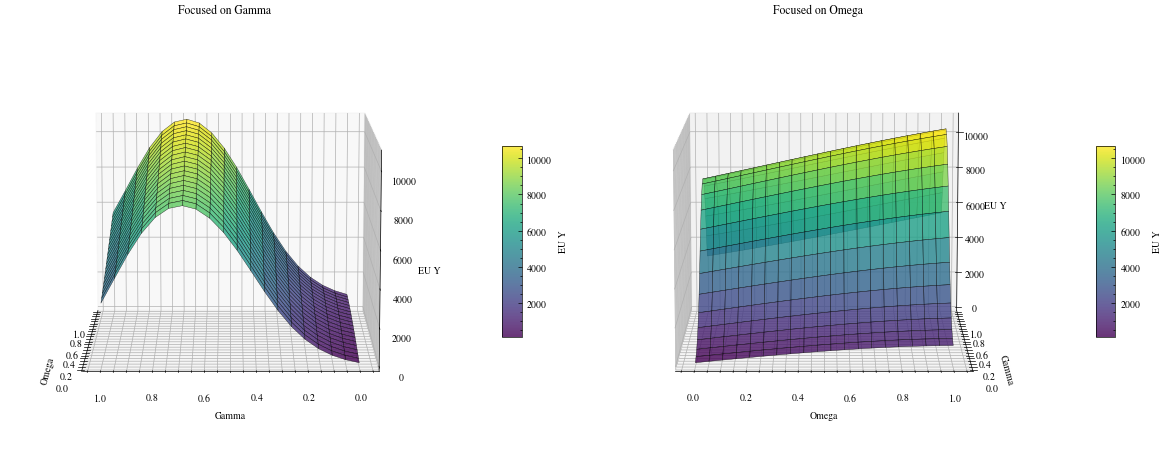

In [85]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

# Filter for theta == 0
df_plot = df_eu_summary[df_eu_summary['theta'] == 0]

# Create grid
omega_vals = np.sort(df_plot['omega'].unique())
gamma_vals = np.sort(df_plot['gamma'].unique())
OMEGA, GAMMA = np.meshgrid(omega_vals, gamma_vals)

# Pivot data into grid
Z = df_plot.pivot(index='gamma', columns='omega', values='Y_EU').values

fig, axes = plt.subplots(1, 2, figsize=(12, 5), subplot_kw={'projection': '3d'})

for ax in axes:
    surf = ax.plot_surface(
        OMEGA, GAMMA, Z,
        cmap=CMAP,
        alpha=0.8,
        edgecolor='k',
        linewidth=0.3,
        antialiased=True,
        shade=True,
        lightsource=True
    )
    ax.set_xlabel('Omega')
    ax.set_ylabel('Gamma')
    ax.set_zlabel('EU Y')
    cbar = fig.colorbar(surf, ax=ax, shrink=0.4, aspect=10, pad=0.1)
    cbar.set_label('EU Y')

# Left plot: focused on gamma axis
axes[0].view_init(elev=10, azim=180)
axes[0].set_title('Focused on Gamma')

# Right plot: focused on omega axis
axes[1].view_init(elev=10, azim=270)
axes[1].set_title('Focused on Omega')

plt.tight_layout()
plt.show()

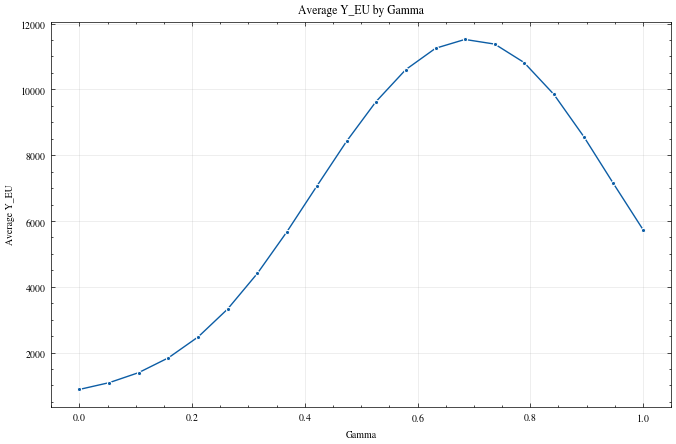

In [86]:
# Plot Y eu per gamma, average all other
df_gamma = df_eu_summary.groupby('gamma')['Y_EU'].mean().reset_index()
plt.figure(figsize=(8, 5))
sns.lineplot(data=df_gamma, x='gamma', y='Y_EU', marker='o')
plt.title('Average Y_EU by Gamma')
plt.xlabel('Gamma')
plt.ylabel('Average Y_EU')
plt.grid(True)
plt.show()

## Wedge matrix

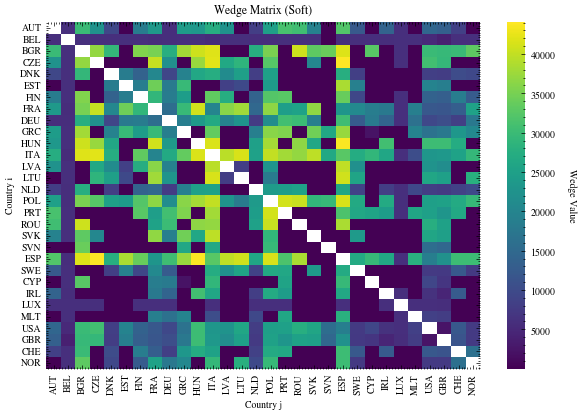

In [87]:
# Plot a wedge matrix across all pairs we have as a heatmap.
df_wedge_soft = pd.read_excel(xls, 'Wedge_Soft', index_col=0)

# Set diagonal to nan since there is nothing to show for this.
for i in range(df_wedge_soft.shape[0]):
    df_wedge_soft.iat[i, i] = np.nan

# Use sns heatmap
plt.figure()
sns.heatmap(df_wedge_soft, cmap=CMAP)
plt.title('Wedge Matrix (Soft)')
plt.xlabel('Country j')
plt.ylabel('Country i')
# Add colorbar description
cbar = plt.gcf().axes[-1].set_ylabel('Wedge Value', rotation=270, labelpad=15)
plt.show()

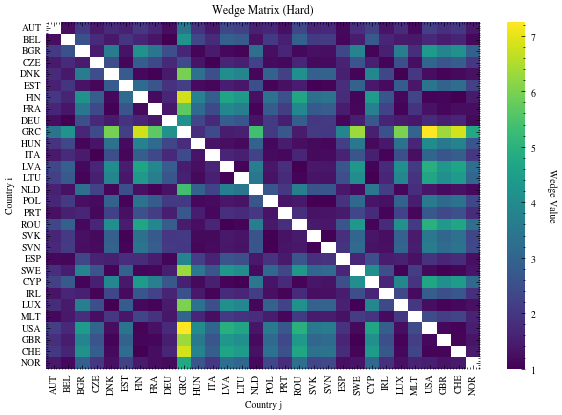

In [88]:
# Plot a wedge matrix across all pairs we have as a heatmap.

df_wedge_hard = pd.read_excel(xls, 'Wedge_Hard', index_col=0)

# Set diagonal to nan since there is nothing to show for this.
for i in range(df_wedge_hard.shape[0]):
    df_wedge_hard.iat[i, i] = np.nan

# Use sns heatmap
plt.figure()
sns.heatmap(df_wedge_hard, cmap=CMAP)
plt.title('Wedge Matrix (Hard)')
plt.xlabel('Country j')
plt.ylabel('Country i')
# Add colorbar description
cbar = plt.gcf().axes[-1].set_ylabel('Wedge Value', rotation=270, labelpad=15)
plt.show()

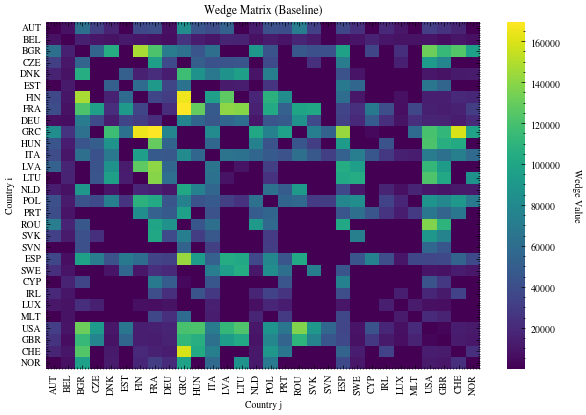

In [89]:
# Wedge baseline

df_wedge_baseline = pd.read_excel(xls, 'Wedge_Baseline', index_col=0)

# Use sns heatmap
plt.figure()
sns.heatmap(df_wedge_baseline, cmap=CMAP)
plt.title('Wedge Matrix (Baseline)')
plt.xlabel('Country j')
plt.ylabel('Country i')
# Add colorbar description
cbar = plt.gcf().axes[-1].set_ylabel('Wedge Value', rotation=270, labelpad=15)
plt.show()

In [90]:
# Get diagonal
diag_wedge = pd.Series(np.diag(df_wedge_baseline), index=df_wedge_baseline.index)
print(diag_wedge.sort_values().head(3))
print("...")
print(diag_wedge.sort_values().tail(3))

SVN    0.012005
LVA    0.057260
EST    0.072359
dtype: float64
...
ITA    158.174184
FRA    169.535273
DEU    226.514685
dtype: float64


## Gini index across EU across parameters

In [91]:
# We want to analyse how the wedges impact the wealth across the EU countries.

def gini(array):
    """Calculate the Gini coefficient of a numpy array."""
    # Based on bottom eq: http://www.statsdirect.com/help/generatedimages/equations/equation154.svg
    # All values are treated equally, arrays must be 1d:
    array = array.flatten()
    if np.amin(array) < 0:
        array -= np.amin(array)  # Values cannot be negative
    array += 0.0000001  # Values cannot be 0
    array = np.sort(array)  # Sort smallest to largest
    index = np.arange(1, array.shape[0] + 1)  # Index per array element
    n = array.shape[0]  # Number of array elements
    return ((np.sum((2 * index - n - 1) * array)) / (n * np.sum(array)))

In [92]:
# Run without extrenes
exclude = ["IRL", "LUX", "CHE", "SVK", "CYP", "MLT"]
df_output_country_EU_extr = df_output_country_EU[~df_output_country_EU['country'].isin(exclude)]

### Output (Y)

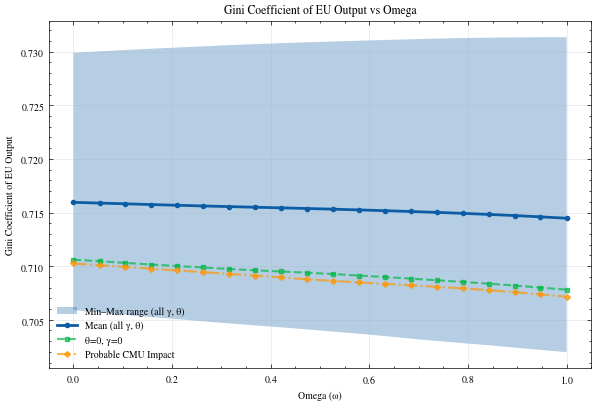

In [93]:
# x-axis: omega
# y-axis: gini index with uncertainty band (min/max across gamma, theta)

# Calculate gini statistics for output for each unique omega
gini_stats_by_omega = []
for omega in sorted(df_output_country_EU['omega'].unique()):
    subset = df_output_country_EU[df_output_country_EU['omega'] == omega]
    subset = subset[subset['theta'] == 0]  # Focus on no TFP case
    subset = subset[subset['gamma'] == 0]  # Focus on gamma = 0 case
    
    output_values = subset['y_cmu'].values
    gini_value = gini(output_values)
    gini_stats_by_omega.append({
        'omega': omega,
        'gini': gini_value
    })

gini_by_omega_df = pd.DataFrame(gini_stats_by_omega)
gini_by_omega_df = gini_by_omega_df.sort_values('omega')

# Compute min/max gini across all (gamma, theta) combinations for each omega
gini_minmax_by_omega = []
for omega in sorted(df_output_country_EU['omega'].unique()):
    subset = df_output_country_EU[df_output_country_EU['omega'] == omega]
    
    gini_values = []
    for gamma in subset['gamma'].unique():
        for theta in subset['theta'].unique():
            subsubset = subset[(subset['gamma'] == gamma) & (subset['theta'] == theta)]
            if len(subsubset) > 0:
                output_values = subsubset['y_cmu'].values
                gini_values.append(gini(output_values))
    
    if gini_values:
        gini_minmax_by_omega.append({
            'omega': omega,
            'gini_min': np.min(gini_values),
            'gini_max': np.max(gini_values),
            'gini_mean': np.mean(gini_values)
        })

gini_minmax_df = pd.DataFrame(gini_minmax_by_omega).sort_values('omega')

plt.figure()
# Fill between min and max
plt.fill_between(gini_minmax_df['omega'], gini_minmax_df['gini_min'], gini_minmax_df['gini_max'], 
                 alpha=0.3, label='Min–Max range (all γ, θ)')
# Plot mean as line
plt.plot(gini_minmax_df['omega'], gini_minmax_df['gini_mean'], marker='o', linewidth=2, 
         label='Mean (all γ, θ)', color='C0')
# Overlay the specific case (θ=0, γ=0)
plt.plot(gini_by_omega_df['omega'], gini_by_omega_df['gini'], marker='s', linestyle='--', 
         linewidth=1.5, label='θ=0, γ=0', color='C1', alpha=0.7)
# Overlay line for most probable case (θ=CMU_THETA, γ=CMU_GAMMA)
most_probable = df_output_country_EU[(df_output_country_EU['theta'] == CMU_THETA) & (df_output_country_EU['gamma'] == CMU_GAMMA)].copy()
most_probable = most_probable.groupby('omega')['y_cmu'].apply(lambda x: gini(x.values)).reset_index(name='gini')
plt.plot(most_probable['omega'], most_probable['gini'], marker='D', linestyle='-.', 
         linewidth=1.5, label="Probable CMU Impact", color='C2', alpha=0.7)

plt.xlabel('Omega (ω)')
plt.ylabel('Gini Coefficient of EU Output')
plt.title('Gini Coefficient of EU Output vs Omega')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

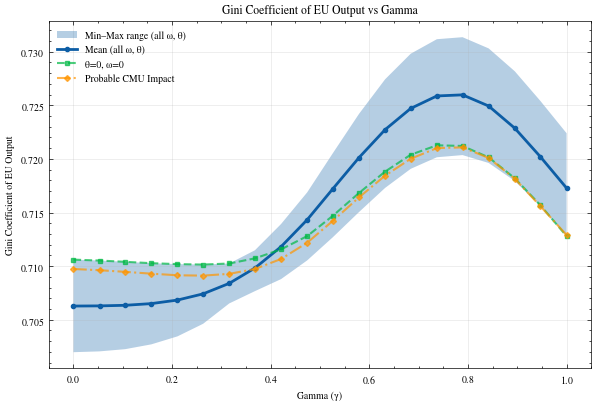

In [94]:
# x-axis: gamma
# y-axis: gini index with uncertainty band (min/max across omega, theta)

# Calculate gini statistics for output for each unique gamma
gini_stats_by_gamma = []
for gamma in sorted(df_output_country_EU['gamma'].unique()):
    subset = df_output_country_EU[df_output_country_EU['gamma'] == gamma]
    subset = subset[subset['theta'] == 0]  # Focus on no TFP case
    subset = subset[subset['omega'] == 0]  # Focus on omega = 0 case
    
    output_values = subset['y_cmu'].values
    gini_value = gini(output_values)
    gini_stats_by_gamma.append({
        'gamma': gamma,
        'gini': gini_value
    })

gini_by_gamma_df = pd.DataFrame(gini_stats_by_gamma)
gini_by_gamma_df = gini_by_gamma_df.sort_values('gamma')

# Compute min/max gini across all (omega, theta) combinations for each gamma
gini_minmax_by_gamma = []
for gamma in sorted(df_output_country_EU['gamma'].unique()):
    subset = df_output_country_EU[df_output_country_EU['gamma'] == gamma]
    
    gini_values = []
    for omega in subset['omega'].unique():
        for theta in subset['theta'].unique():
            subsubset = subset[(subset['omega'] == omega) & (subset['theta'] == theta)]
            if len(subsubset) > 0:
                output_values = subsubset['y_cmu'].values
                gini_values.append(gini(output_values))
    
    if gini_values:
        gini_minmax_by_gamma.append({
            'gamma': gamma,
            'gini_min': np.min(gini_values),
            'gini_max': np.max(gini_values),
            'gini_mean': np.mean(gini_values)
        })

gini_minmax_df = pd.DataFrame(gini_minmax_by_gamma).sort_values('gamma')

plt.figure()
# Fill between min and max
plt.fill_between(gini_minmax_df['gamma'], gini_minmax_df['gini_min'], gini_minmax_df['gini_max'], 
                 alpha=0.3, label='Min–Max range (all ω, θ)')
# Plot mean as line
plt.plot(gini_minmax_df['gamma'], gini_minmax_df['gini_mean'], marker='o', linewidth=2, 
         label='Mean (all ω, θ)', color='C0')
# Overlay the specific case (θ=0, ω=0)
plt.plot(gini_by_gamma_df['gamma'], gini_by_gamma_df['gini'], marker='s', linestyle='--', 
         linewidth=1.5, label='θ=0, ω=0', color='C1', alpha=0.7)

# Overlay line for most probable case (θ=CMU_THETA, omega=CMU_OMEGA)
most_probable = df_output_country_EU[(df_output_country_EU['theta'] == CMU_THETA) & (df_output_country_EU['omega'] == CMU_OMEGA)]
most_probable = most_probable.groupby('gamma')['y_cmu'].apply(lambda x: gini(x.values)).reset_index(name='gini')
plt.plot(most_probable['gamma'], most_probable['gini'], marker='D', linestyle='-.', 
         linewidth=1.5, label="Probable CMU Impact", color='C2', alpha=0.7)

plt.xlabel('Gamma (γ)')
plt.ylabel('Gini Coefficient of EU Output')
plt.title('Gini Coefficient of EU Output vs Gamma')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

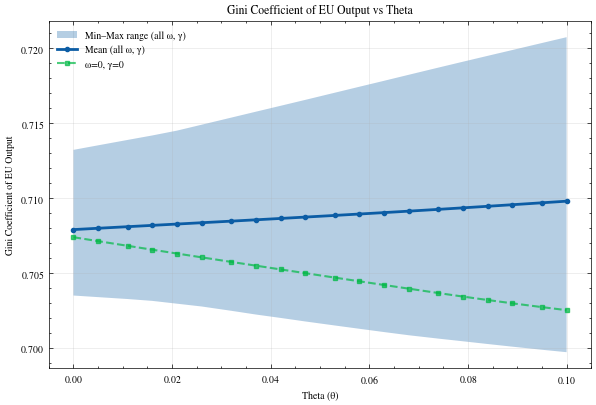

In [95]:
# x-axis: theta
# y-axis: gini index with uncertainty band (min/max across omega, gamma)

# Calculate gini statistics for output for each unique theta
gini_stats_by_theta = []
for theta in sorted(df_output_country['theta'].unique()):
    subset = df_output_country[df_output_country['theta'] == theta]
    subset = subset[subset['omega'] == 0]  # Focus on omega = 0 case
    subset = subset[subset['gamma'] == 0]  # Focus on gamma = 0 case
    
    output_values = subset['y_cmu'].values
    gini_value = gini(output_values)
    gini_stats_by_theta.append({
        'theta': theta,
        'gini': gini_value
    })

gini_by_theta_df = pd.DataFrame(gini_stats_by_theta)
gini_by_theta_df = gini_by_theta_df.sort_values('theta')

# Compute min/max gini across all (omega, gamma) combinations for each theta
gini_minmax_by_theta = []
for theta in sorted(df_output_country['theta'].unique()):
    subset = df_output_country[df_output_country['theta'] == theta]
    
    gini_values = []
    for omega in subset['omega'].unique():
        for gamma in subset['gamma'].unique():
            subsubset = subset[(subset['omega'] == omega) & (subset['gamma'] == gamma)]
            if len(subsubset) > 0:
                output_values = subsubset['y_cmu'].values
                gini_values.append(gini(output_values))
    
    if gini_values:
        gini_minmax_by_theta.append({
            'theta': theta,
            'gini_min': np.min(gini_values),
            'gini_max': np.max(gini_values),
            'gini_mean': np.mean(gini_values)
        })

gini_minmax_df = pd.DataFrame(gini_minmax_by_theta).sort_values('theta')

plt.figure()
# Fill between min and max
plt.fill_between(gini_minmax_df['theta'], gini_minmax_df['gini_min'], gini_minmax_df['gini_max'], 
                 alpha=0.3, label='Min–Max range (all ω, γ)')
# Plot mean as line
plt.plot(gini_minmax_df['theta'], gini_minmax_df['gini_mean'], marker='o', linewidth=2, 
         label='Mean (all ω, γ)', color='C0')
# Overlay the specific case (ω=0, γ=0)
plt.plot(gini_by_theta_df['theta'], gini_by_theta_df['gini'], marker='s', linestyle='--', 
         linewidth=1.5, label='ω=0, γ=0', color='C1', alpha=0.7)

plt.xlabel('Theta (θ)')
plt.ylabel('Gini Coefficient of EU Output')
plt.title('Gini Coefficient of EU Output vs Theta')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [96]:
# Build 3D dataframe: compute Gini for all (omega, gamma, theta) combinations

gini_3d_df = df_output_country.groupby(['omega', 'gamma', 'theta']).apply(
    lambda subset: gini(subset['y_cmu'].values),
    include_groups=False
).reset_index(name='gini')

print(f"3D Gini dataframe shape: {gini_3d_df.shape}")
print(f"Gini range: [{gini_3d_df['gini'].min():.4f}, {gini_3d_df['gini'].max():.4f}]")
print(gini_3d_df.head(10))

3D Gini dataframe shape: (8000, 4)
Gini range: [0.6997, 0.7207]
   omega  gamma  theta      gini
0    0.0    0.0  0.000  0.707379
1    0.0    0.0  0.005  0.707117
2    0.0    0.0  0.011  0.706805
3    0.0    0.0  0.016  0.706546
4    0.0    0.0  0.021  0.706289
5    0.0    0.0  0.026  0.706035
6    0.0    0.0  0.032  0.705732
7    0.0    0.0  0.037  0.705481
8    0.0    0.0  0.042  0.705230
9    0.0    0.0  0.047  0.704981


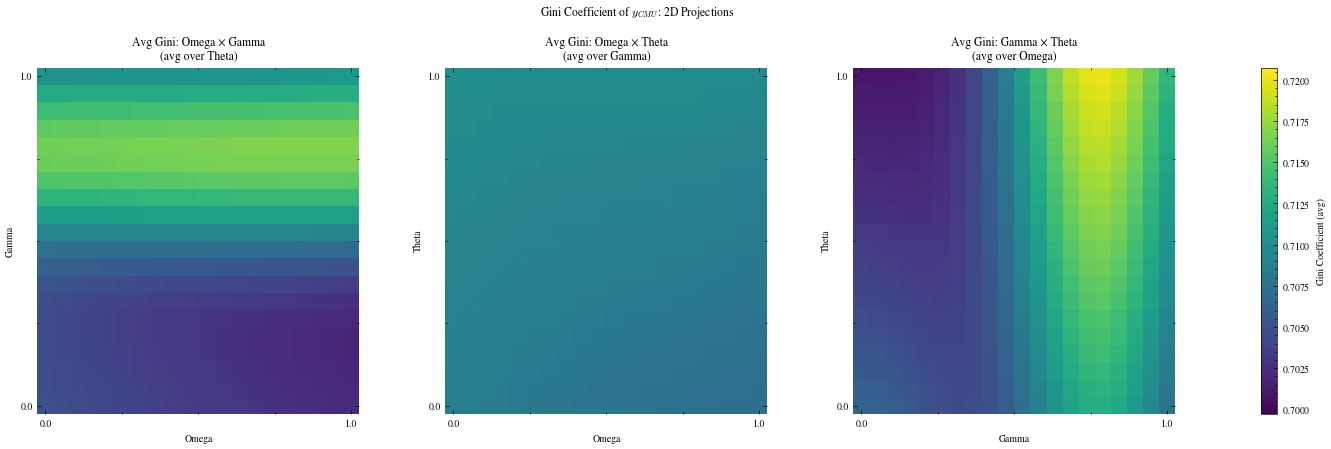

In [97]:
# 2D heatmap projections of Gini across parameter pairs
# Each heatmap averages the Gini over the third (omitted) parameter
# Contour isolines added on top

projection_configs = [
    ('omega', 'gamma', 'theta', 'Omega', 'Gamma',  'Avg Gini: Omega × Gamma\n(avg over Theta)'),
    ('omega', 'theta', 'gamma', 'Omega', 'Theta',  'Avg Gini: Omega × Theta\n(avg over Gamma)'),
    ('gamma', 'theta', 'omega', 'Gamma', 'Theta',  'Avg Gini: Gamma × Theta\n(avg over Omega)'),
]

gini_vmin = gini_3d_df['gini'].min()
gini_vmax = gini_3d_df['gini'].max()
gini_norm = plt.Normalize(gini_vmin, gini_vmax)

# Use gridspec: 3 equal heatmap cols + 1 narrow colorbar col
fig = plt.figure(figsize=(16, 4.5))
gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1, 0.05], wspace=0.35)
axes = [fig.add_subplot(gs[0, i]) for i in range(3)]
cax  = fig.add_subplot(gs[0, 3])

N_CONTOURS = 7

for ax, (x_col, y_col, avg_col, xlabel, ylabel, title) in zip(axes, projection_configs):
    pivot = gini_3d_df.groupby([y_col, x_col])['gini'].mean().unstack()
    sns.heatmap(
        pivot,
        ax=ax,
        cmap=CMAP,
        cbar=False,
        xticklabels=False,
        yticklabels=False,
        vmin=gini_vmin,
        vmax=gini_vmax,
    )
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.invert_yaxis()

    # Show only min and max tick labels on each axis
    n_x = pivot.shape[1]
    n_y = pivot.shape[0]
    ax.set_xticks([0.5, n_x - 0.5])
    ax.set_xticklabels(['0.0', '1.0'])
    ax.set_yticks([0.5, n_y - 0.5])
    ax.set_yticklabels(['0.0', '1.0'])

    # Overlay contour isolines
    # heatmap cells are centred at 0.5, 1.5, ..., so use cell-centre coordinates
    x_centres = np.arange(0.5, n_x)
    y_centres = np.arange(0.5, n_y)
    Z = pivot.values  # rows = y_col, cols = x_col (already inverted by invert_yaxis)
    # cs = ax.contour(
    #     x_centres, y_centres, Z,
    #     levels=N_CONTOURS,
    #     colors='white',
    #     linewidths=0.5,
    #     alpha=0.75,
    # )
    # ax.clabel(cs, inline=True, fontsize=7, fmt='%.4f')

# Colorbar in its own dedicated axes
sm = plt.cm.ScalarMappable(cmap=CMAP, norm=gini_norm)
sm.set_array([])
fig.colorbar(sm, cax=cax).set_label('Gini Coefficient (avg)')

plt.suptitle('Gini Coefficient of $y_{CMU}$: 2D Projections', y=1.02)
plt.show()

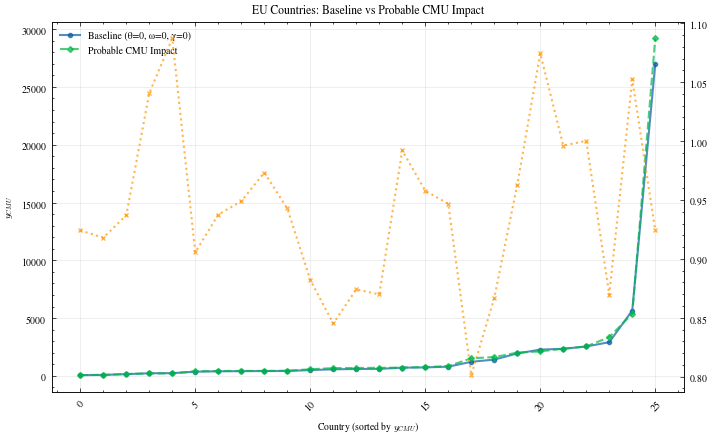

In [98]:
# Plot ln Y for best and worst. Sorting by 
# ln Y. So we line plot and see how the curve
# changes for baseline and most probable case.

baseline = df_output_country_EU[(df_output_country_EU['theta'] == 0) & (df_output_country_EU['omega'] == 0) & (df_output_country_EU['gamma'] == 0)]
most_probable = df_output_country_EU[(df_output_country_EU['theta'] == CMU_THETA) & (df_output_country_EU['omega'] == CMU_OMEGA) & (df_output_country_EU['gamma'] == CMU_GAMMA)]

# Sort by y_cmu
baseline = baseline.sort_values('y_cmu')
most_probable = most_probable.sort_values('y_cmu')

# # Log
# baseline['y_cmu'] = np.log(baseline['y_cmu'])
# most_probable['y_cmu'] = np.log(most_probable['y_cmu'])

plt.figure()
# Baseline
plt.plot(baseline['y_cmu'].values, marker='o', linestyle='-', linewidth=1.5, label='Baseline (θ=0, ω=0, γ=0)', color='C0', alpha=0.7)
# Most probable case
plt.plot(most_probable['y_cmu'].values, marker='D', linestyle='--', linewidth=1.5, label='Probable CMU Impact', color='C1', alpha=0.7)
plt.xlabel('Country (sorted by $y_{CMU}$)')
plt.ylabel('$y_{CMU}$')
plt.title('EU Countries: Baseline vs Probable CMU Impact')
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.tight_layout()

# second axis plot difference
plt.twinx().plot(baseline['y_cmu'].values / most_probable['y_cmu'].values, marker='x', linestyle=':', linewidth=1.5, label='Difference (Baseline - Probable)', color='C2', alpha=0.7)
plt.show()

### Wealth (K)

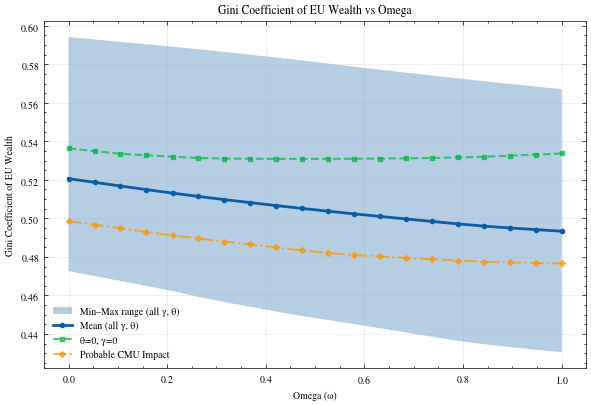

In [99]:
# x-axis: omega
# y-axis: gini index with uncertainty band (min/max across gamma, theta)

# Calculate gini statistics for output for each unique omega
gini_stats_by_omega = []
for omega in sorted(df_output_country_EU['omega'].unique()):
    subset = df_output_country_EU[df_output_country_EU['omega'] == omega]
    subset = subset[subset['theta'] == 0]  # Focus on no TFP case
    subset = subset[subset['gamma'] == 0]  # Focus on gamma = 0 case
    
    output_values = subset['k_cmu'].values
    gini_value = gini(output_values)
    gini_stats_by_omega.append({
        'omega': omega,
        'gini': gini_value
    })

gini_by_omega_df = pd.DataFrame(gini_stats_by_omega)
gini_by_omega_df = gini_by_omega_df.sort_values('omega')

# Compute min/max gini across all (gamma, theta) combinations for each omega
gini_minmax_by_omega = []
for omega in sorted(df_output_country_EU['omega'].unique()):
    subset = df_output_country_EU[df_output_country_EU['omega'] == omega]
    
    gini_values = []
    for gamma in subset['gamma'].unique():
        for theta in subset['theta'].unique():
            subsubset = subset[(subset['gamma'] == gamma) & (subset['theta'] == theta)]
            if len(subsubset) > 0:
                output_values = subsubset['k_cmu'].values
                gini_values.append(gini(output_values))
    
    if gini_values:
        gini_minmax_by_omega.append({
            'omega': omega,
            'gini_min': np.min(gini_values),
            'gini_max': np.max(gini_values),
            'gini_mean': np.mean(gini_values)
        })

gini_minmax_df = pd.DataFrame(gini_minmax_by_omega).sort_values('omega')

plt.figure()
# Fill between min and max
plt.fill_between(gini_minmax_df['omega'], gini_minmax_df['gini_min'], gini_minmax_df['gini_max'], 
                 alpha=0.3, label='Min–Max range (all γ, θ)')
# Plot mean as line
plt.plot(gini_minmax_df['omega'], gini_minmax_df['gini_mean'], marker='o', linewidth=2, 
         label='Mean (all γ, θ)', color='C0')
# Overlay the specific case (θ=0, γ=0)
plt.plot(gini_by_omega_df['omega'], gini_by_omega_df['gini'], marker='s', linestyle='--', 
         linewidth=1.5, label='θ=0, γ=0', color='C1', alpha=0.7)
# Overlay line for most probable case (θ=CMU_THETA, γ=CMU_GAMMA)
most_probable = df_output_country_EU[(df_output_country_EU['theta'] == CMU_THETA) & (df_output_country_EU['gamma'] == CMU_GAMMA)].copy()
most_probable = most_probable.groupby('omega')['k_cmu'].apply(lambda x: gini(x.values)).reset_index(name='gini')
plt.plot(most_probable['omega'], most_probable['gini'], marker='D', linestyle='-.', 
         linewidth=1.5, label="Probable CMU Impact", color='C2', alpha=0.7)

plt.xlabel('Omega (ω)')
plt.ylabel('Gini Coefficient of EU Wealth')
plt.title('Gini Coefficient of EU Wealth vs Omega')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

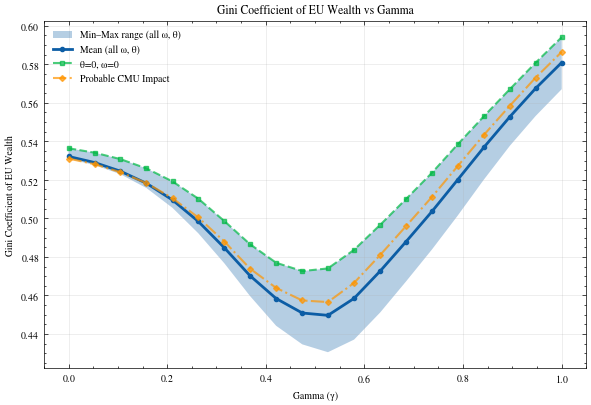

In [100]:
# x-axis: gamma
# y-axis: gini index with uncertainty band (min/max across omega, theta)

# Calculate gini statistics for output for each unique gamma
gini_stats_by_gamma = []
for gamma in sorted(df_output_country_EU['gamma'].unique()):
    subset = df_output_country_EU[df_output_country_EU['gamma'] == gamma]
    subset = subset[subset['theta'] == 0]  # Focus on no TFP case
    subset = subset[subset['omega'] == 0]  # Focus on omega = 0 case
    
    output_values = subset['k_cmu'].values
    gini_value = gini(output_values)
    gini_stats_by_gamma.append({
        'gamma': gamma,
        'gini': gini_value
    })

gini_by_gamma_df = pd.DataFrame(gini_stats_by_gamma)
gini_by_gamma_df = gini_by_gamma_df.sort_values('gamma')

# Compute min/max gini across all (omega, theta) combinations for each gamma
gini_minmax_by_gamma = []
for gamma in sorted(df_output_country_EU['gamma'].unique()):
    subset = df_output_country_EU[df_output_country_EU['gamma'] == gamma]
    
    gini_values = []
    for omega in subset['omega'].unique():
        for theta in subset['theta'].unique():
            subsubset = subset[(subset['omega'] == omega) & (subset['theta'] == theta)]
            if len(subsubset) > 0:
                output_values = subsubset['k_cmu'].values
                gini_values.append(gini(output_values))
    
    if gini_values:
        gini_minmax_by_gamma.append({
            'gamma': gamma,
            'gini_min': np.min(gini_values),
            'gini_max': np.max(gini_values),
            'gini_mean': np.mean(gini_values)
        })

gini_minmax_df = pd.DataFrame(gini_minmax_by_gamma).sort_values('gamma')

plt.figure()
# Fill between min and max
plt.fill_between(gini_minmax_df['gamma'], gini_minmax_df['gini_min'], gini_minmax_df['gini_max'], 
                 alpha=0.3, label='Min–Max range (all ω, θ)')
# Plot mean as line
plt.plot(gini_minmax_df['gamma'], gini_minmax_df['gini_mean'], marker='o', linewidth=2, 
         label='Mean (all ω, θ)', color='C0')
# Overlay the specific case (θ=0, ω=0)
plt.plot(gini_by_gamma_df['gamma'], gini_by_gamma_df['gini'], marker='s', linestyle='--', 
         linewidth=1.5, label='θ=0, ω=0', color='C1', alpha=0.7)

# Overlay line for most probable case (θ=CMU_THETA, omega=CMU_OMEGA)
most_probable = df_output_country_EU[(df_output_country_EU['theta'] == CMU_THETA) & (df_output_country_EU['omega'] == CMU_OMEGA)]
most_probable = most_probable.groupby('gamma')['k_cmu'].apply(lambda x: gini(x.values)).reset_index(name='gini')
plt.plot(most_probable['gamma'], most_probable['gini'], marker='D', linestyle='-.', 
         linewidth=1.5, label="Probable CMU Impact", color='C2', alpha=0.7)

plt.xlabel('Gamma (γ)')
plt.ylabel('Gini Coefficient of EU Wealth')
plt.title('Gini Coefficient of EU Wealth vs Gamma')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

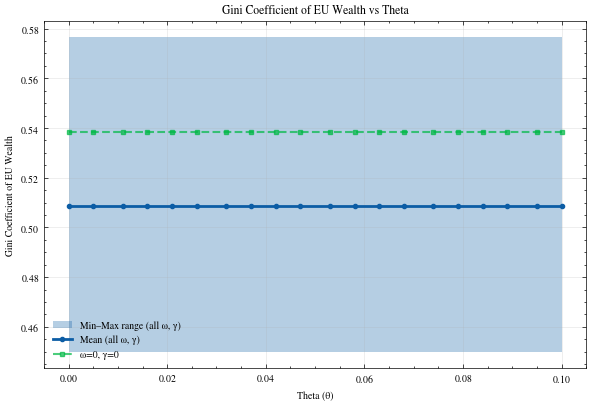

In [101]:
# x-axis: theta
# y-axis: gini index with uncertainty band (min/max across omega, gamma)

# Calculate gini statistics for output for each unique theta
gini_stats_by_theta = []
for theta in sorted(df_output_country['theta'].unique()):
    subset = df_output_country[df_output_country['theta'] == theta]
    subset = subset[subset['omega'] == 0]  # Focus on omega = 0 case
    subset = subset[subset['gamma'] == 0]  # Focus on gamma = 0 case
    
    output_values = subset['k_cmu'].values
    gini_value = gini(output_values)
    gini_stats_by_theta.append({
        'theta': theta,
        'gini': gini_value
    })

gini_by_theta_df = pd.DataFrame(gini_stats_by_theta)
gini_by_theta_df = gini_by_theta_df.sort_values('theta')

# Compute min/max gini across all (omega, gamma) combinations for each theta
gini_minmax_by_theta = []
for theta in sorted(df_output_country['theta'].unique()):
    subset = df_output_country[df_output_country['theta'] == theta]
    
    gini_values = []
    for omega in subset['omega'].unique():
        for gamma in subset['gamma'].unique():
            subsubset = subset[(subset['omega'] == omega) & (subset['gamma'] == gamma)]
            if len(subsubset) > 0:
                output_values = subsubset['k_cmu'].values
                gini_values.append(gini(output_values))
    
    if gini_values:
        gini_minmax_by_theta.append({
            'theta': theta,
            'gini_min': np.min(gini_values),
            'gini_max': np.max(gini_values),
            'gini_mean': np.mean(gini_values)
        })

gini_minmax_df = pd.DataFrame(gini_minmax_by_theta).sort_values('theta')

plt.figure()
# Fill between min and max
plt.fill_between(gini_minmax_df['theta'], gini_minmax_df['gini_min'], gini_minmax_df['gini_max'], 
                 alpha=0.3, label='Min–Max range (all ω, γ)')
# Plot mean as line
plt.plot(gini_minmax_df['theta'], gini_minmax_df['gini_mean'], marker='o', linewidth=2, 
         label='Mean (all ω, γ)', color='C0')
# Overlay the specific case (ω=0, γ=0)
plt.plot(gini_by_theta_df['theta'], gini_by_theta_df['gini'], marker='s', linestyle='--', 
         linewidth=1.5, label='ω=0, γ=0', color='C1', alpha=0.7)

plt.xlabel('Theta (θ)')
plt.ylabel('Gini Coefficient of EU Wealth')
plt.title('Gini Coefficient of EU Wealth vs Theta')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [102]:
# Build 3D dataframe: compute Gini for all (omega, gamma, theta) combinations

gini_3d_df = df_output_country.groupby(['omega', 'gamma', 'theta']).apply(
    lambda subset: gini(subset['k_cmu'].values),
    include_groups=False
).reset_index(name='gini')

print(f"3D Gini dataframe shape: {gini_3d_df.shape}")
print(f"Gini range: [{gini_3d_df['gini'].min():.4f}, {gini_3d_df['gini'].max():.4f}]")
print(gini_3d_df.head(10))

3D Gini dataframe shape: (8000, 4)
Gini range: [0.4498, 0.5765]
   omega  gamma  theta      gini
0    0.0    0.0  0.000  0.538482
1    0.0    0.0  0.005  0.538482
2    0.0    0.0  0.011  0.538482
3    0.0    0.0  0.016  0.538482
4    0.0    0.0  0.021  0.538482
5    0.0    0.0  0.026  0.538482
6    0.0    0.0  0.032  0.538482
7    0.0    0.0  0.037  0.538482
8    0.0    0.0  0.042  0.538482
9    0.0    0.0  0.047  0.538482


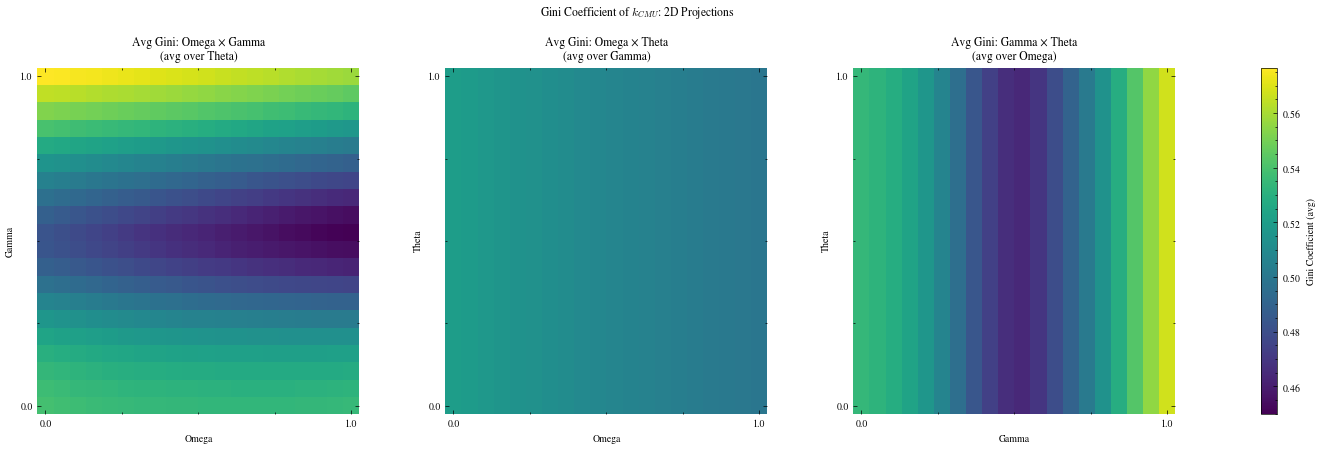

In [103]:
# 2D heatmap projections of Gini across parameter pairs
# Each heatmap averages the Gini over the third (omitted) parameter
# Contour isolines added on top

projection_configs = [
    ('omega', 'gamma', 'theta', 'Omega', 'Gamma',  'Avg Gini: Omega × Gamma\n(avg over Theta)'),
    ('omega', 'theta', 'gamma', 'Omega', 'Theta',  'Avg Gini: Omega × Theta\n(avg over Gamma)'),
    ('gamma', 'theta', 'omega', 'Gamma', 'Theta',  'Avg Gini: Gamma × Theta\n(avg over Omega)'),
]

gini_vmin = gini_3d_df['gini'].min()
gini_vmax = gini_3d_df['gini'].max()
gini_norm = plt.Normalize(gini_vmin, gini_vmax)

# Use gridspec: 3 equal heatmap cols + 1 narrow colorbar col
fig = plt.figure(figsize=(16, 4.5))
gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1, 0.05], wspace=0.35)
axes = [fig.add_subplot(gs[0, i]) for i in range(3)]
cax  = fig.add_subplot(gs[0, 3])

N_CONTOURS = 7

for ax, (x_col, y_col, avg_col, xlabel, ylabel, title) in zip(axes, projection_configs):
    pivot = gini_3d_df.groupby([y_col, x_col])['gini'].mean().unstack()
    sns.heatmap(
        pivot,
        ax=ax,
        cmap=CMAP,
        cbar=False,
        xticklabels=False,
        yticklabels=False,
        vmin=gini_vmin,
        vmax=gini_vmax,
    )
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.invert_yaxis()

    # Show only min and max tick labels on each axis
    n_x = pivot.shape[1]
    n_y = pivot.shape[0]
    ax.set_xticks([0.5, n_x - 0.5])
    ax.set_xticklabels(['0.0', '1.0'])
    ax.set_yticks([0.5, n_y - 0.5])
    ax.set_yticklabels(['0.0', '1.0'])

    # Overlay contour isolines
    # heatmap cells are centred at 0.5, 1.5, ..., so use cell-centre coordinates
    x_centres = np.arange(0.5, n_x)
    y_centres = np.arange(0.5, n_y)
    Z = pivot.values  # rows = y_col, cols = x_col (already inverted by invert_yaxis)
    # cs = ax.contour(
    #     x_centres, y_centres, Z,
    #     levels=N_CONTOURS,
    #     colors='white',
    #     linewidths=0.5,
    #     alpha=0.75,
    # )
    # ax.clabel(cs, inline=True, fontsize=7, fmt='%.4f')

# Colorbar in its own dedicated axes
sm = plt.cm.ScalarMappable(cmap=CMAP, norm=gini_norm)
sm.set_array([])
fig.colorbar(sm, cax=cax).set_label('Gini Coefficient (avg)')

plt.suptitle('Gini Coefficient of $k_{CMU}$: 2D Projections', y=1.02)
plt.show()

## Stock Market Cap per Country

In [104]:
# Plot histogram of stock market cap across the countries
df_final = pd.read_csv("Data/Clean/Final-v4.csv")
df_final

,iso3_i,iso3_j,year,total_pip_million_usd_i,total_pip_million_usd_j,a_ij,r_i,r_j,Y_i,k_i,...,legal_origin,language_proximity,lang_share,lang_official,legal_origin_i,legal_origin_j,fta_wto,d_ling,eu_i,eu_j
0,ABW,ABW,2000,NaN,NaN,NaN,NaN,NaN,3982.696289,11437.366211,...,1.0,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0
1,ABW,ABW,2001,NaN,NaN,NaN,NaN,NaN,3918.971436,11965.093750,...,1.0,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0
2,ABW,ABW,2002,NaN,NaN,NaN,NaN,NaN,3923.781006,12594.469727,...,1.0,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0
3,ABW,ABW,2003,NaN,NaN,NaN,NaN,NaN,3944.353027,13318.708008,...,1.0,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0
4,ABW,ABW,2004,NaN,NaN,NaN,NaN,NaN,4243.611328,14101.028320,...,1.0,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1535269,ZWE,ZWE,2021,NaN,NaN,NaN,NaN,NaN,44440.199219,110979.773438,...,1.0,NaN,1.0,1.0,2.0,2.0,0.0,0.0,0.0,0.0
1535270,ZWE,ZWE,2022,NaN,NaN,NaN,NaN,NaN,47147.550781,114134.882812,...,1.0,NaN,1.0,1.0,2.0,2.0,0.0,0.0,0.0,0.0
1535271,ZWE,ZWE,2023,NaN,NaN,NaN,NaN,NaN,49685.757812,118669.257812,...,1.0,NaN,1.0,1.0,2.0,2.0,0.0,0.0,0.0,0.0
1535272,ZWE,ZWE,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,NaN,1.0,1.0,2.0,2.0,0.0,0.0,0.0,0.0


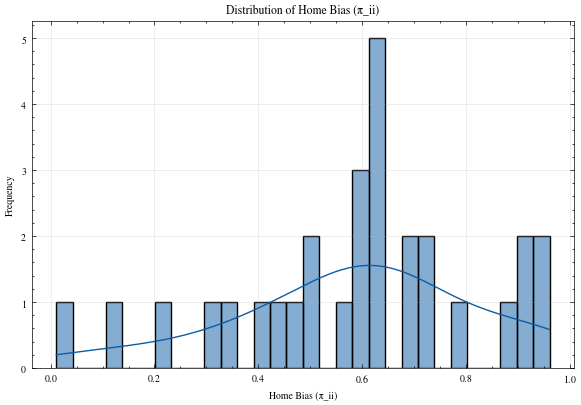

Countries with Home Bias (π_ii) below 0.2:
['IRL', 'MLT']


In [105]:
# Plot home bias across countries
# Home bias = pi_ii (share of domestic holdings in total portfolio)

df_portfolio = pd.read_excel(xls, 'Portfolio_Data', index_col=0)
df_portfolio_arr = df_portfolio.values
# Flatten with numpy, get full matrix flat
portfolio_flat = df_portfolio_arr.flatten()
# Attach index (iso3_i, iso3_j) and make into series
portfolio_series = pd.Series(portfolio_flat, index=pd.MultiIndex.from_product([df_portfolio.index, df_portfolio.columns], names=['iso3_i', 'iso3_j']))

# Plot distribution of home bias (pi_ii)
home_bias = portfolio_series[portfolio_series.index.get_level_values('iso3_i') == portfolio_series.index.get_level_values('iso3_j')]
home_bias = home_bias.dropna()

plt.figure()
sns.histplot(home_bias, bins=30, kde=True)
plt.title('Distribution of Home Bias (π_ii)')
plt.xlabel('Home Bias (π_ii)')
plt.ylabel('Frequency')
plt.grid()
plt.show()

# Print the countries with below 0.2 in home bias
low_home_bias = home_bias[home_bias < 0.2]
print("Countries with Home Bias (π_ii) below 0.2:")
print(low_home_bias.index.get_level_values('iso3_i').unique().tolist())

## Map

In [106]:
world = gpd.read_file("Data/europe.geo.json")
world.head()

,featurecla,scalerank,labelrank,sovereignt,sov_a3,adm0_dif,level,type,tlc,admin,...,fclass_id,fclass_pl,fclass_gr,fclass_it,fclass_nl,fclass_se,fclass_bd,fclass_ua,filename,geometry
0,Admin-0 country,1,3,Ukraine,UKR,0,2,Sovereign country,1,Ukraine,...,None,None,None,None,None,None,None,None,UKR.geojson,"MULTIPOLYGON (((38.21436 47.09146, 38.17832 47..."
1,Admin-0 country,1,4,Belarus,BLR,0,2,Sovereign country,1,Belarus,...,None,None,None,None,None,None,None,None,BLR.geojson,"POLYGON ((31.76338 52.10107, 31.57373 52.10811..."
2,Admin-0 country,3,5,Lithuania,LTU,0,2,Sovereign country,1,Lithuania,...,None,None,None,None,None,None,None,None,LTU.geojson,"MULTIPOLYGON (((20.95781 55.27891, 20.8998 55...."
3,Admin-0 country,5,2,Russia,RUS,0,2,Sovereign country,1,Russia,...,None,None,None,None,None,None,None,None,RUS.geojson,"MULTIPOLYGON (((145.88154 43.45952, 145.89561 ..."
4,Admin-0 country,1,5,Czechia,CZE,0,2,Sovereign country,1,Czechia,...,None,None,None,None,None,None,None,None,CZE.geojson,"POLYGON ((18.83223 49.51079, 18.80703 49.50923..."


In [107]:
# Use pycountry to get the iso3 codes
import pycountry

# PyCountry mapping
records = []
for c in pycountry.countries:
    records.append({
        "country_name": c.name,
        "iso3":         c.alpha_3,
        "iso2":         c.alpha_2,
        "iso_numeric":  c.numeric,
    })

df_iso = pd.DataFrame(records)
# # Limit it to COUNTRIES
# df_iso_countries = df_iso[df_iso['iso3'].isin(COUNTRIES)]
# Set if in EU27
df_iso['in_EU27'] = df_iso['iso3'].apply(lambda x: 1 if x in EU27 else 0)
print(df_iso.shape)

(249, 5)


In [108]:
# Join world and df_iso_countries on admin and country name
world = world.merge(df_iso, left_on='admin', right_on='country_name', how='left')
world["in_EU27"] = world["in_EU27"].fillna(0).astype(int)
world.head()

,featurecla,scalerank,labelrank,sovereignt,sov_a3,adm0_dif,level,type,tlc,admin,...,fclass_se,fclass_bd,fclass_ua,filename,geometry,country_name,iso3,iso2,iso_numeric,in_EU27
0,Admin-0 country,1,3,Ukraine,UKR,0,2,Sovereign country,1,Ukraine,...,None,None,None,UKR.geojson,"MULTIPOLYGON (((38.21436 47.09146, 38.17832 47...",Ukraine,UKR,UA,804,0
1,Admin-0 country,1,4,Belarus,BLR,0,2,Sovereign country,1,Belarus,...,None,None,None,BLR.geojson,"POLYGON ((31.76338 52.10107, 31.57373 52.10811...",Belarus,BLR,BY,112,0
2,Admin-0 country,3,5,Lithuania,LTU,0,2,Sovereign country,1,Lithuania,...,None,None,None,LTU.geojson,"MULTIPOLYGON (((20.95781 55.27891, 20.8998 55....",Lithuania,LTU,LT,440,1
3,Admin-0 country,5,2,Russia,RUS,0,2,Sovereign country,1,Russia,...,None,None,None,RUS.geojson,"MULTIPOLYGON (((145.88154 43.45952, 145.89561 ...",NaN,NaN,NaN,NaN,0
4,Admin-0 country,1,5,Czechia,CZE,0,2,Sovereign country,1,Czechia,...,None,None,None,CZE.geojson,"POLYGON ((18.83223 49.51079, 18.80703 49.50923...",Czechia,CZE,CZ,203,1


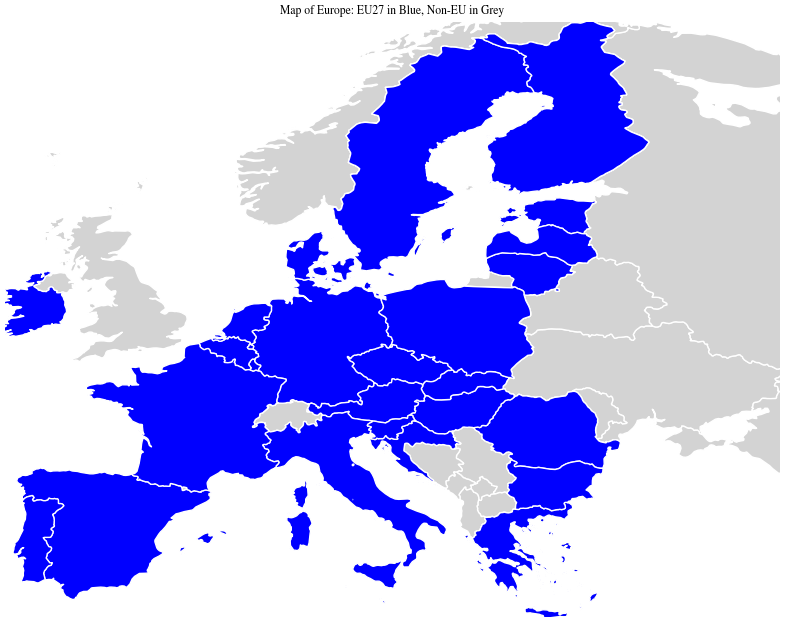

In [109]:
# gpd.plotting.plot_dataframe(world, column='sov_a3')
# EU countries
world_eu = world[world['in_EU27'] == 1].copy()
world_noneu = world[world['in_EU27'] == 0].copy()

fig, ax = plt.subplots(figsize=(10, 8))

world.plot(ax=ax, color='lightgrey', edgecolor='white')
world_eu.plot(ax=ax, color='blue', edgecolor='white')

ax.set_title('Map of Europe: EU27 in Blue, Non-EU in Grey')
ax.set_axis_off()
ax.set_xlim(-10, 40)
ax.set_ylim(35, 70)

plt.show()

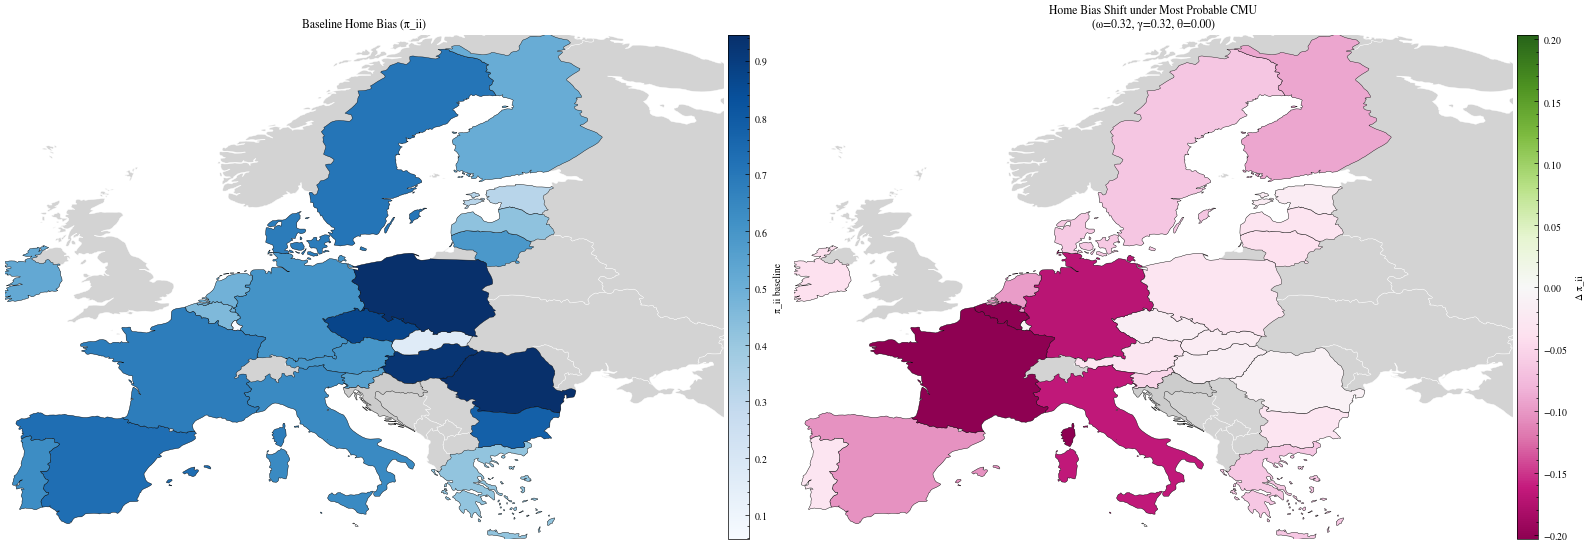

In [110]:
# Map: Home bias — baseline level (left) and shift under most probable CMU (right)
from mpl_toolkits.axes_grid1 import make_axes_locatable

df_hb = df_output_country_EU[
    (df_output_country_EU['theta'] == CMU_THETA) &
    (df_output_country_EU['omega'] == CMU_OMEGA) &
    (df_output_country_EU['gamma'] == CMU_GAMMA)
][['country', 'pi_home_baseline', 'pi_home_cmu', 'd_pi_home', 'd_pi_home_pct']].copy()

world_eu_hb = world_eu.merge(df_hb, left_on='iso3', right_on='country', how='left')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

_WATER   = '#a8d8ea'
_MISSING = dict(color='#cccccc', edgecolor='black', label='No data')

# ── Left: baseline home bias level ──────────────────────────
ax = axes[0]
ax.set_facecolor(_WATER)

vmin_b = world_eu_hb['pi_home_baseline'].quantile(0.05)
vmax_b = world_eu_hb['pi_home_baseline'].quantile(0.95)
norm_b = plt.Normalize(vmin=vmin_b, vmax=vmax_b)

world_noneu.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.3)
world_eu_hb.plot(ax=ax, column='pi_home_baseline', cmap='Blues',
                 edgecolor='black', linewidth=0.3, legend=False,
                 norm=norm_b, missing_kwds=_MISSING)

sm_b = plt.cm.ScalarMappable(cmap='Blues', norm=norm_b)
sm_b.set_array(world_eu_hb['pi_home_baseline'].dropna().values)
div_b = make_axes_locatable(ax)
cax_b = div_b.append_axes("right", size="3%", pad=0.04)
fig.colorbar(sm_b, cax=cax_b).set_label('π_ii baseline')

ax.set_title('Baseline Home Bias (π_ii)')
ax.set_axis_off()
ax.set_xlim(-10, 40)
ax.set_ylim(35, 70)
ax.set_aspect('equal')

# ── Right: shift Δπ_ii under most probable CMU ──────────────
ax = axes[1]
ax.set_facecolor(_WATER)

vlim = world_eu_hb['d_pi_home'].abs().quantile(0.95)
norm_d = mcolors.TwoSlopeNorm(vmin=-vlim, vcenter=0, vmax=vlim)

world_noneu.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.3)
world_eu_hb.plot(ax=ax, column='d_pi_home', cmap='PiYG',
                 edgecolor='black', linewidth=0.3, legend=False,
                 norm=norm_d, missing_kwds=_MISSING)

# # Annotate each country with the pct change
# for _, row in world_eu_hb.dropna(subset=['d_pi_home_pct']).iterrows():
#     pt = row.geometry.centroid
#     if -10 <= pt.x <= 40 and 35 <= pt.y <= 70:
#         ax.annotate(f"{row['d_pi_home_pct']:.1f}%", xy=(pt.x, pt.y),
#                     ha='center', va='center', fontsize=5.5,
#                     color='black', fontweight='bold')

sm_d = plt.cm.ScalarMappable(cmap='PiYG', norm=norm_d)
sm_d.set_array(world_eu_hb['d_pi_home'].dropna().values)
div_d = make_axes_locatable(ax)
cax_d = div_d.append_axes("right", size="3%", pad=0.04)
fig.colorbar(sm_d, cax=cax_d).set_label('Δ π_ii')

ax.set_title(f'Home Bias Shift under Most Probable CMU\n(ω={CMU_OMEGA:.2f}, γ={CMU_GAMMA:.2f}, θ={CMU_THETA:.2f})')
ax.set_axis_off()
ax.set_xlim(-10, 40)
ax.set_ylim(35, 70)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

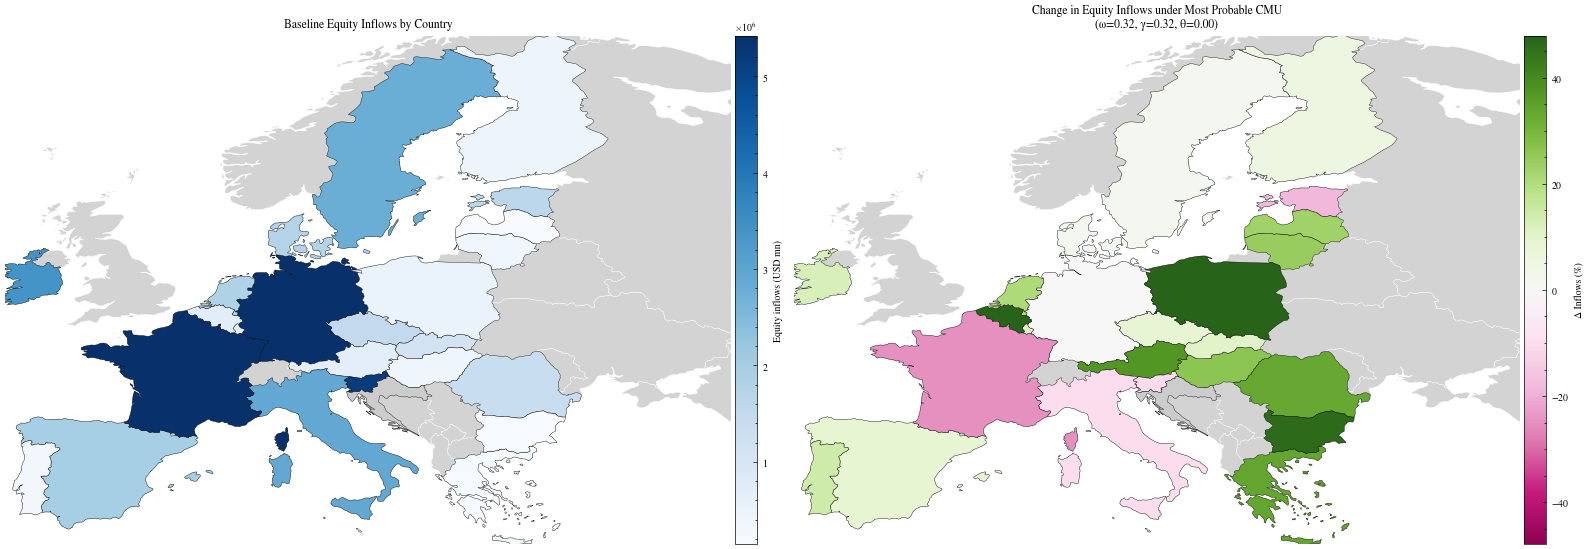

In [111]:
# Map: Flow of money change — baseline inflows (left) and shift under most probable CMU (right)
from mpl_toolkits.axes_grid1 import make_axes_locatable

df_flows = pd.read_excel(xls, 'Portfolio_Flows')

# Total equity inflows received by each destination country j
# baseline scenario = omega=0, gamma=0
df_baseline_flows = (
    df_flows[df_flows['scenario'] == 'baseline']
    .groupby('iso3_j')['k_flow'].sum()
    .reset_index()
    .rename(columns={'iso3_j': 'country', 'k_flow': 'k_inflow_baseline'})
)

df_prob_flows = (
    df_flows[df_flows['scenario'] == 'most_probable']
    .groupby('iso3_j')['k_flow'].sum()
    .reset_index()
    .rename(columns={'iso3_j': 'country', 'k_flow': 'k_inflow_cmu'})
)

df_flow_change = df_baseline_flows.merge(df_prob_flows, on='country')
df_flow_change['dk_inflow']     = df_flow_change['k_inflow_cmu'] - df_flow_change['k_inflow_baseline']
df_flow_change['dk_inflow_pct'] = df_flow_change['dk_inflow'] / df_flow_change['k_inflow_baseline'] * 100

world_eu_flow = world_eu.merge(df_flow_change, left_on='iso3', right_on='country', how='left')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

_WATER   = '#a8d8ea'
_MISSING = dict(color='#cccccc', edgecolor='black', label='No data')

# ── Left: baseline total inflows ─────────────────────────────
ax = axes[0]
ax.set_facecolor(_WATER)

vmin_b = world_eu_flow['k_inflow_baseline'].quantile(0.05)
vmax_b = world_eu_flow['k_inflow_baseline'].quantile(0.95)
norm_b = plt.Normalize(vmin=vmin_b, vmax=vmax_b)

world_noneu.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.3)
world_eu_flow.plot(ax=ax, column='k_inflow_baseline', cmap='Blues',
                   edgecolor='black', linewidth=0.3, legend=False,
                   norm=norm_b, missing_kwds=_MISSING)

sm_b = plt.cm.ScalarMappable(cmap='Blues', norm=norm_b)
sm_b.set_array(world_eu_flow['k_inflow_baseline'].dropna().values)
div_b = make_axes_locatable(ax)
cax_b = div_b.append_axes("right", size="3%", pad=0.04)
fig.colorbar(sm_b, cax=cax_b).set_label('Equity inflows (USD mn)')

ax.set_title('Baseline Equity Inflows by Country')
ax.set_axis_off()
ax.set_xlim(-10, 40)
ax.set_ylim(35, 70)
ax.set_aspect('equal')

# ── Right: shift in inflows under most probable CMU ──────────
ax = axes[1]
ax.set_facecolor(_WATER)

vlim = world_eu_flow['dk_inflow_pct'].abs().quantile(0.95)
norm_d = mcolors.TwoSlopeNorm(vmin=-vlim, vcenter=0, vmax=vlim)

world_noneu.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.3)
world_eu_flow.plot(ax=ax, column='dk_inflow_pct', cmap='PiYG',
                   edgecolor='black', linewidth=0.3, legend=False,
                   norm=norm_d, missing_kwds=_MISSING)

sm_d = plt.cm.ScalarMappable(cmap='PiYG', norm=norm_d)
sm_d.set_array(world_eu_flow['dk_inflow_pct'].dropna().values)
div_d = make_axes_locatable(ax)
cax_d = div_d.append_axes("right", size="3%", pad=0.04)
fig.colorbar(sm_d, cax=cax_d).set_label('Δ Inflows (%)')

ax.set_title(f'Change in Equity Inflows under Most Probable CMU\n(ω={CMU_OMEGA:.2f}, γ={CMU_GAMMA:.2f}, θ={CMU_THETA:.2f})')
ax.set_axis_off()
ax.set_xlim(-10, 40)
ax.set_ylim(35, 70)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

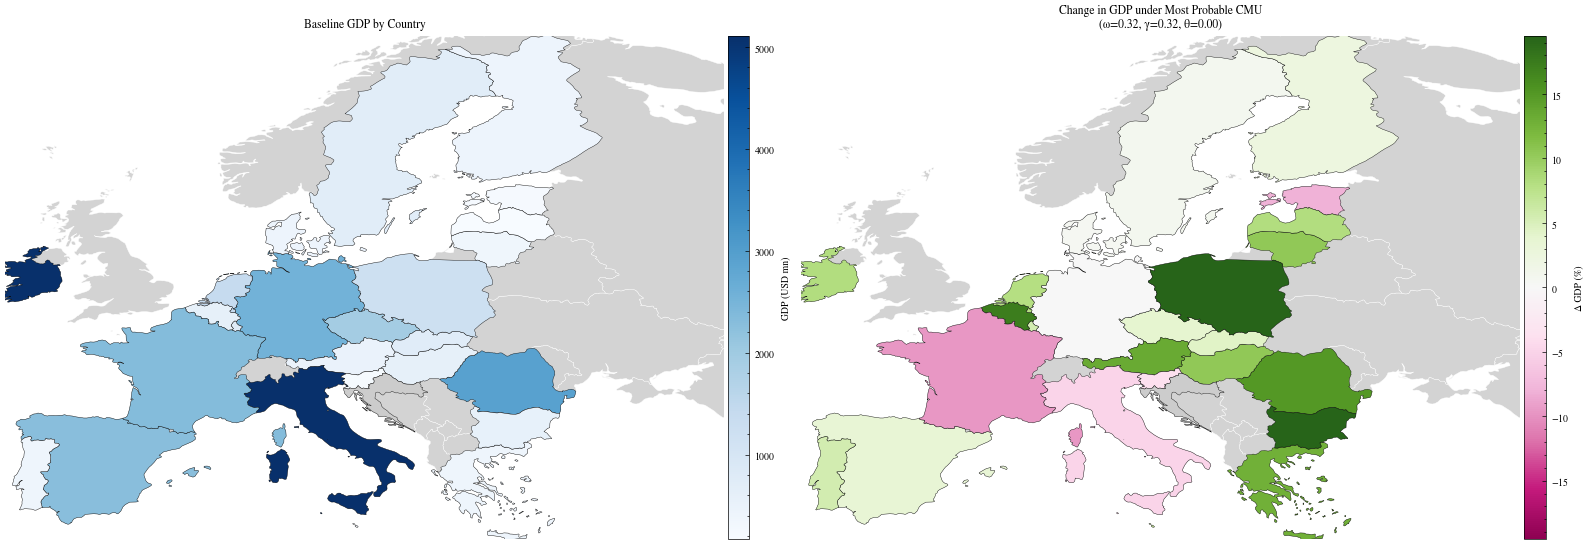

In [112]:
# MAP GDP
# Map: GDP baseline level (left) and % change under most probable CMU (right)
from mpl_toolkits.axes_grid1 import make_axes_locatable

df_gdp_mp = df_output_country_EU[
    (df_output_country_EU['theta'] == CMU_THETA) &
    (df_output_country_EU['omega'] == CMU_OMEGA) &
    (df_output_country_EU['gamma'] == CMU_GAMMA)
].copy()

df_gdp_mp['dy_pct'] = (df_gdp_mp['y_cmu'] - df_gdp_mp['y_baseline']) / df_gdp_mp['y_baseline'] * 100

world_eu_gdp = world_eu.merge(
    df_gdp_mp[['country', 'y_baseline', 'dy_pct']],
    left_on='iso3', right_on='country', how='left'
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

_WATER   = '#a8d8ea'
_MISSING = dict(color='#cccccc', edgecolor='black', label='No data')

# ── Left: baseline GDP ───────────────────────────────────────
ax = axes[0]
ax.set_facecolor(_WATER)

vmin_b = world_eu_gdp['y_baseline'].quantile(0.05)
vmax_b = world_eu_gdp['y_baseline'].quantile(0.95)
norm_b = plt.Normalize(vmin=vmin_b, vmax=vmax_b)

world_noneu.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.3)
world_eu_gdp.plot(ax=ax, column='y_baseline', cmap='Blues',
                  edgecolor='black', linewidth=0.3, legend=False,
                  norm=norm_b, missing_kwds=_MISSING)

sm_b = plt.cm.ScalarMappable(cmap='Blues', norm=norm_b)
sm_b.set_array(world_eu_gdp['y_baseline'].dropna().values)
div_b = make_axes_locatable(ax)
cax_b = div_b.append_axes("right", size="3%", pad=0.04)
fig.colorbar(sm_b, cax=cax_b).set_label('GDP (USD mn)')

ax.set_title('Baseline GDP by Country')
ax.set_axis_off()
ax.set_xlim(-10, 40)
ax.set_ylim(35, 70)
ax.set_aspect('equal')

# ── Right: % change in GDP under most probable CMU ───────────
ax = axes[1]
ax.set_facecolor(_WATER)

vlim = world_eu_gdp['dy_pct'].abs().quantile(0.95)
norm_d = mcolors.TwoSlopeNorm(vmin=-vlim, vcenter=0, vmax=vlim)

world_noneu.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.3)
world_eu_gdp.plot(ax=ax, column='dy_pct', cmap='PiYG',
                  edgecolor='black', linewidth=0.3, legend=False,
                  norm=norm_d, missing_kwds=_MISSING)

sm_d = plt.cm.ScalarMappable(cmap='PiYG', norm=norm_d)
sm_d.set_array(world_eu_gdp['dy_pct'].dropna().values)
div_d = make_axes_locatable(ax)
cax_d = div_d.append_axes("right", size="3%", pad=0.04)
fig.colorbar(sm_d, cax=cax_d).set_label('Δ GDP (%)')

ax.set_title(f'Change in GDP under Most Probable CMU\n(ω={CMU_OMEGA:.2f}, γ={CMU_GAMMA:.2f}, θ={CMU_THETA:.2f})')
ax.set_axis_off()
ax.set_xlim(-10, 40)
ax.set_ylim(35, 70)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()


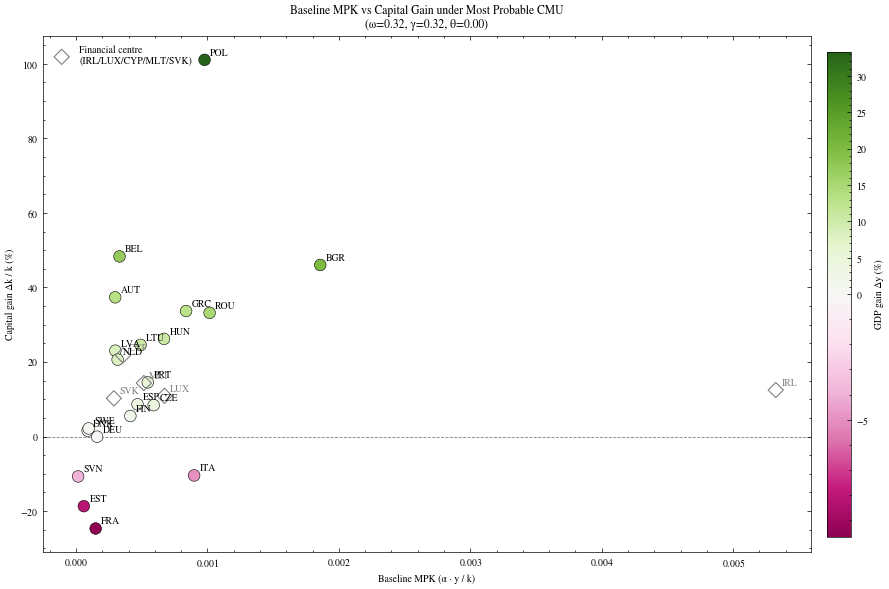

In [113]:
# Scatter: baseline MPK vs capital gain under most probable CMU
# Each point = one EU27 country; colour = GDP gain (dy_pct)

df_scatter = df_output_country_EU[
    (df_output_country_EU['theta'] == CMU_THETA) &
    (df_output_country_EU['omega'] == CMU_OMEGA) &
    (df_output_country_EU['gamma'] == CMU_GAMMA)
][['country', 'mpk_baseline', 'dk_pct', 'dy_pct', 'dA_pct', 'is_financial_ctr']].copy()

# Separate financial centres (distorted data) from regular countries
df_main = df_scatter[df_scatter['is_financial_ctr'] == 0]
df_fc   = df_scatter[df_scatter['is_financial_ctr'] == 1]

fig, ax = plt.subplots(figsize=(9, 6))

# Colour by dy_pct
vmin_c = df_main['dy_pct'].min()
vmax_c = df_main['dy_pct'].max()
norm_c = mcolors.TwoSlopeNorm(vmin=vmin_c, vcenter=0, vmax=vmax_c)
cmap_c = plt.cm.PiYG

sc = ax.scatter(
    df_main['mpk_baseline'],
    df_main['dk_pct'],
    c=df_main['dy_pct'],
    cmap=cmap_c,
    norm=norm_c,
    s=70,
    zorder=3,
    edgecolors='black',
    linewidths=0.4,
)

# Plot financial centres as hollow grey markers
ax.scatter(
    df_fc['mpk_baseline'],
    df_fc['dk_pct'],
    c='none',
    edgecolors='grey',
    linewidths=0.8,
    s=60,
    zorder=3,
    label='Financial centre\n(IRL/LUX/CYP/MLT/SVK)',
    marker='D',
)

# Country labels
for _, row in df_scatter.iterrows():
    ax.annotate(
        row['country'],
        xy=(row['mpk_baseline'], row['dk_pct']),
        xytext=(4, 3),
        textcoords='offset points',
        fontsize=7,
        color='grey' if row['is_financial_ctr'] else 'black',
    )

# Horizontal zero line
ax.axhline(0, color='black', linewidth=0.6, linestyle='--', alpha=0.5)

cb = fig.colorbar(sc, ax=ax, fraction=0.03, pad=0.02)
cb.set_label('GDP gain Δy (%)')

ax.set_xlabel('Baseline MPK (α · y / k)')
ax.set_ylabel('Capital gain Δk / k (%)')
ax.set_title(f'Baseline MPK vs Capital Gain under Most Probable CMU\n'
             f'(ω={CMU_OMEGA:.2f}, γ={CMU_GAMMA:.2f}, θ={CMU_THETA:.2f})')
ax.legend(fontsize=7, loc='upper left')
plt.tight_layout()
plt.show()

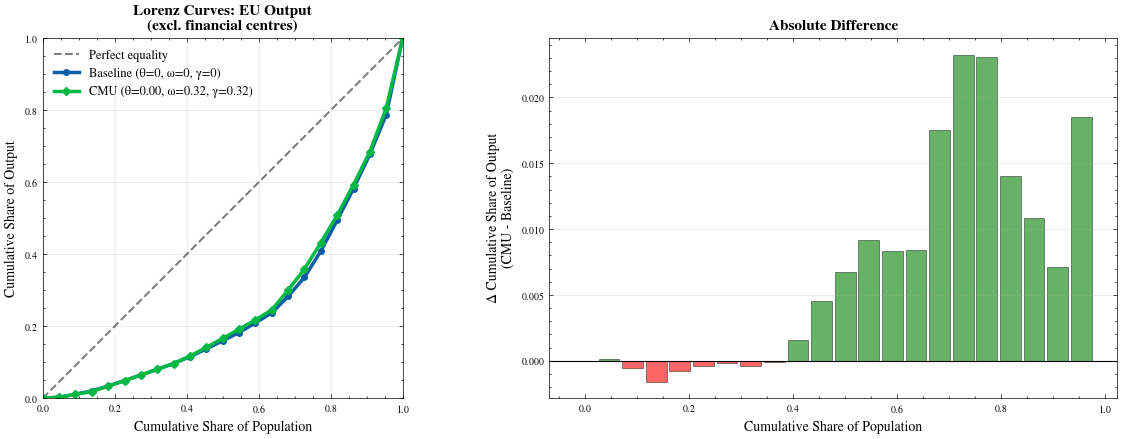

Gini Coefficient (Baseline): 0.5028
Gini Coefficient (Most Probable CMU): 0.4893
Change in Gini: -0.0135

Max absolute difference in cumulative output: 0.0232 at pop share 0.73
Mean absolute difference: 0.0071


In [114]:
# Lorenz curve: baseline vs most probable CMU scenario
# Financial centres excluded from distributional analysis
FINANCIAL_CENTRES = ["IRL", "LUX", "CYP", "MLT"]
df_eu_excl = df_output_country_EU[~df_output_country_EU['country'].isin(FINANCIAL_CENTRES)].copy()

def lorenz_curve(values):
    """Return (cum_population_share, cum_wealth_share) for a Lorenz curve."""
    values = np.sort(np.array(values, dtype=float))
    cum_wealth = np.cumsum(values) / values.sum()
    cum_pop = np.arange(1, len(values) + 1) / len(values)
    # Prepend origin
    return np.concatenate([[0], cum_pop]), np.concatenate([[0], cum_wealth])

baseline      = df_eu_excl[(df_eu_excl['theta'] == 0) & (df_eu_excl['omega'] == 0) & (df_eu_excl['gamma'] == 0)]
most_probable = df_eu_excl[(df_eu_excl['theta'] == CMU_THETA) & (df_eu_excl['omega'] == CMU_OMEGA) & (df_eu_excl['gamma'] == CMU_GAMMA)]

cum_pop_base, cum_wealth_base = lorenz_curve(baseline['y_cmu'].values)
cum_pop_cmu,  cum_wealth_cmu  = lorenz_curve(most_probable['y_cmu'].values)

# Interpolate to same grid for difference calculation
cum_wealth_cmu_interp = np.interp(cum_pop_base, cum_pop_cmu, cum_wealth_cmu)
wealth_diff = cum_wealth_cmu_interp - cum_wealth_base

# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# ─── Left: Standard Lorenz Curves ───────────────────────────
ax = axes[0]
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Perfect equality', alpha=0.5)
ax.plot(cum_pop_base, cum_wealth_base, marker='o', linewidth=2.5, 
        label='Baseline (θ=0, ω=0, γ=0)', color='C0', markersize=4)
ax.plot(cum_pop_cmu, cum_wealth_cmu, marker='D', linewidth=2.5, 
        label=f'CMU (θ={CMU_THETA:.2f}, ω={CMU_OMEGA:.2f}, γ={CMU_GAMMA:.2f})', 
        color='C1', markersize=4)
ax.set_xlabel('Cumulative Share of Population', fontsize=10)
ax.set_ylabel('Cumulative Share of Output', fontsize=10)
ax.set_title('Lorenz Curves: EU Output\n(excl. financial centres)', fontsize=11, fontweight='bold')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9, loc='upper left')
ax.set_aspect('equal')

# ─── Right: Absolute Difference ────────────────────────────
ax = axes[1]
colors = ['red' if d < 0 else 'green' for d in wealth_diff]
ax.bar(cum_pop_base[:-1], wealth_diff[:-1], width=0.04, color=colors, alpha=0.6, edgecolor='black', linewidth=0.5)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Cumulative Share of Population', fontsize=10)
ax.set_ylabel('Δ Cumulative Share of Output\n(CMU - Baseline)', fontsize=10)
ax.set_title('Absolute Difference', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print statistics
gini_baseline = gini(baseline['y_cmu'].values)
gini_cmu = gini(most_probable['y_cmu'].values)
max_diff = np.max(np.abs(wealth_diff))
max_diff_idx = np.argmax(np.abs(wealth_diff))

print(f"Gini Coefficient (Baseline): {gini_baseline:.4f}")
print(f"Gini Coefficient (Most Probable CMU): {gini_cmu:.4f}")
print(f"Change in Gini: {gini_cmu - gini_baseline:+.4f}")
print(f"\nMax absolute difference in cumulative output: {max_diff:.4f} at pop share {cum_pop_base[max_diff_idx]:.2f}")
print(f"Mean absolute difference: {np.mean(np.abs(wealth_diff[:-1])):.4f}")


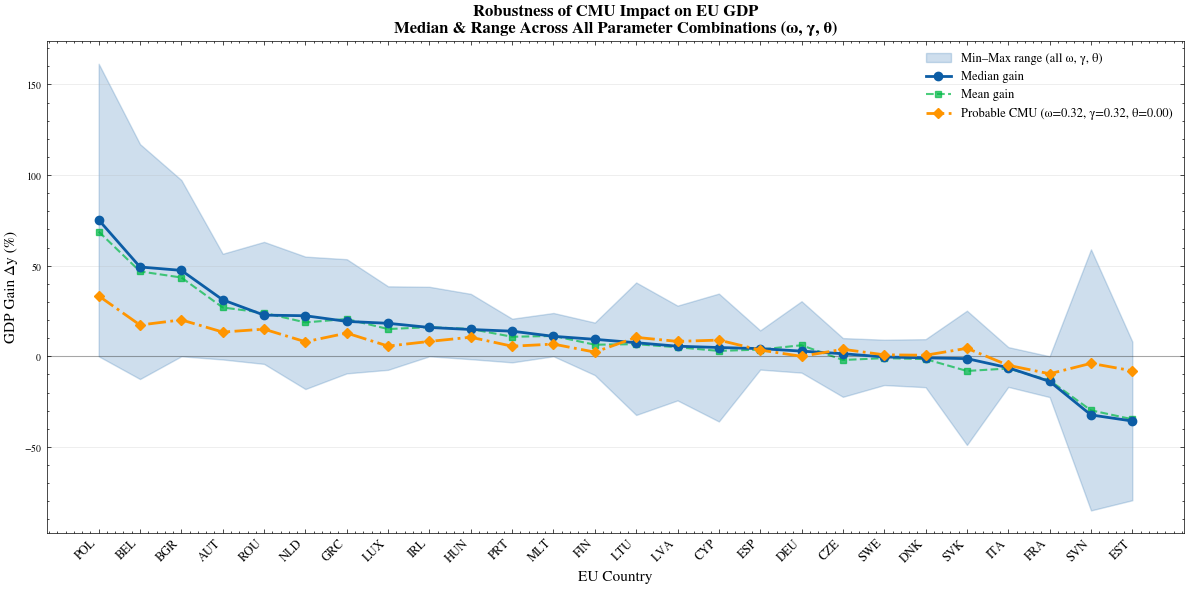

EU GDP Gain Robustness Summary
Country    Probable     Median       Mean         Min          Max          Range       
--------------------------------------------------------------------------------
POL             33.323%      75.266%      68.794%       0.000%     161.416%     161.416%
BEL             17.250%      49.280%      46.833%     -12.556%     117.061%     129.617%
BGR             20.091%      47.397%      43.464%       0.000%      97.232%      97.232%
AUT             13.364%      31.154%      26.930%      -1.761%      56.565%      58.327%
ROU             14.981%      22.710%      23.972%      -4.207%      63.125%      67.332%
NLD              8.000%      22.372%      18.678%     -18.078%      54.994%      73.072%
GRC             12.797%      19.245%      20.570%      -9.437%      53.567%      63.003%
LUX              5.628%      18.201%      15.026%      -7.473%      38.600%      46.072%
IRL              8.202%      15.902%      16.070%       0.000%      38.338%      38.338

In [115]:
# Robustness bands: EU GDP gain - median line + min/max band across all omega*gamma*theta combinations

# For each country, calculate GDP gain across all parameter combinations
df_robustness = []

for country in df_output_country_EU['country'].unique():
    country_data = df_output_country_EU[df_output_country_EU['country'] == country]
    
    # Calculate GDP gain percentage for each parameter combination
    country_data_copy = country_data.copy()
    country_data_copy['dy_pct'] = (country_data_copy['y_cmu'] - country_data_copy['y_baseline']) / country_data_copy['y_baseline'] * 100
    
    # Get all unique parameter combinations
    for (omega, gamma, theta), group in country_data_copy.groupby(['omega', 'gamma', 'theta']):
        dy_pct = group['dy_pct'].values[0]
        df_robustness.append({
            'country': country,
            'omega': omega,
            'gamma': gamma,
            'theta': theta,
            'dy_pct': dy_pct
        })

df_robustness = pd.DataFrame(df_robustness)

# Group by country and calculate statistics
robustness_stats = []
for country in sorted(df_robustness['country'].unique()):
    country_gains = df_robustness[df_robustness['country'] == country]['dy_pct']
    
    robustness_stats.append({
        'country': country,
        'dy_median': country_gains.median(),
        'dy_mean': country_gains.mean(),
        'dy_min': country_gains.min(),
        'dy_max': country_gains.max(),
        'dy_std': country_gains.std()
    })

df_stats = pd.DataFrame(robustness_stats).sort_values('dy_median', ascending=False)

# Get most probable case for each country
most_prob_gains = []
for country in sorted(df_output_country_EU['country'].unique()):
    country_data = df_output_country_EU[
        (df_output_country_EU['country'] == country) &
        (df_output_country_EU['theta'] == CMU_THETA) &
        (df_output_country_EU['omega'] == CMU_OMEGA) &
        (df_output_country_EU['gamma'] == CMU_GAMMA)
    ]
    if len(country_data) > 0:
        dy_pct = (country_data['y_cmu'].values[0] - country_data['y_baseline'].values[0]) / country_data['y_baseline'].values[0] * 100
        most_prob_gains.append({'country': country, 'dy_prob': dy_pct})

df_prob = pd.DataFrame(most_prob_gains)
df_stats = df_stats.merge(df_prob, on='country', how='left')

# Plot robustness bands
fig, ax = plt.subplots(figsize=(12, 6))

x_pos = np.arange(len(df_stats))

# Min-max band (light shading)
ax.fill_between(x_pos, df_stats['dy_min'], df_stats['dy_max'], 
                alpha=0.2, color='C0', label='Min–Max range (all ω, γ, θ)')

# Median line
ax.plot(x_pos, df_stats['dy_median'], marker='o', linewidth=2, 
        markersize=6, color='C0', label='Median gain', zorder=3)

# Mean line (optional, dashed)
ax.plot(x_pos, df_stats['dy_mean'], marker='s', linewidth=1.5, 
        markersize=4, linestyle='--', color='C1', alpha=0.7, label='Mean gain', zorder=2)

# Most probable CMU case
ax.plot(x_pos, df_stats['dy_prob'], marker='D', linewidth=2, 
        markersize=5, linestyle='-.', color='C2', label=f"Probable CMU (ω={CMU_OMEGA:.2f}, γ={CMU_GAMMA:.2f}, θ={CMU_THETA:.2f})", zorder=3)

# Horizontal zero line
ax.axhline(0, color='black', linewidth=0.8, linestyle='-', alpha=0.3)

# Formatting
ax.set_xticks(x_pos)
ax.set_xticklabels(df_stats['country'], rotation=45, ha='right', fontsize=9)
ax.set_xlabel('EU Country', fontsize=11)
ax.set_ylabel('GDP Gain Δy (%)', fontsize=11)
ax.set_title('Robustness of CMU Impact on EU GDP\nMedian & Range Across All Parameter Combinations (ω, γ, θ)', 
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.legend(fontsize=9, loc='best')

plt.tight_layout()
plt.show()

# Print summary statistics
print("EU GDP Gain Robustness Summary")
print("=" * 80)
print(f"{'Country':<10} {'Probable':<12} {'Median':<12} {'Mean':<12} {'Min':<12} {'Max':<12} {'Range':<12}")
print("-" * 80)
for _, row in df_stats.iterrows():
    range_val = row['dy_max'] - row['dy_min']
    print(f"{row['country']:<10} {row['dy_prob']:>11.3f}% {row['dy_median']:>11.3f}% {row['dy_mean']:>11.3f}% {row['dy_min']:>11.3f}% {row['dy_max']:>11.3f}% {range_val:>11.3f}%")
print("-" * 80)

In [116]:
# ── DIVE 1: Full decomposition table for all EU27 (no financial centres) ──
import os; os.makedirs("dive", exist_ok=True)

FOCUS = ["FIN", "SWE", "DEU", "BEL", "DNK", "FRA"]
EU27_NO_FC = [c for c in df_output_country_EU['country'].unique()
              if c not in ["CYP", "MLT", "LUX", "IRL"]]

prob = df_output_country[
    (df_output_country['theta'] == CMU_THETA) &
    (df_output_country['omega'] == CMU_OMEGA) &
    (df_output_country['gamma'] == CMU_GAMMA) &
    (df_output_country['country'].isin(EU27_NO_FC))
][["country", "dy_pct", "dk_pct", "dk_foreign_pct", "d_pi_home_pct",
   "capital_effect_pct", "tfp_effect_pct", "delta_ii",
   "pi_home_baseline", "pi_home_cmu",
   "k_baseline", "k_foreign_baseline", "f_baseline", "f_cmu",
   "s_total_wealth", "R_normalised"]].sort_values("dy_pct")

print("=" * 110)
print("Full decomposition — EU27 excl. financial centres — most probable CMU (ω={:.3f}, γ={:.3f}, θ={:.3f})".format(
    CMU_OMEGA, CMU_GAMMA, CMU_THETA))
print("=" * 110)
print(f"{'Country':<8} {'dy%':>7} {'dk%':>7} {'dkFor%':>8} {'capEff%':>8} {'tfpEff%':>8} "
      f"{'dπHome%':>8} {'π_base':>8} {'π_cmu':>8} {'δ_ii':>8} {'f_base':>9} {'R_norm':>8}")
print("-" * 110)
for _, r in prob.iterrows():
    print(f"{r['country']:<8} {r['dy_pct']:>7.2f} {r['dk_pct']:>7.2f} {r['dk_foreign_pct']:>8.2f} "
          f"{r['capital_effect_pct']:>8.2f} {r['tfp_effect_pct']:>8.2f} "
          f"{r['d_pi_home_pct']:>8.2f} {r['pi_home_baseline']:>8.4f} {r['pi_home_cmu']:>8.4f} "
          f"{r['delta_ii']:>8.4f} {r['f_baseline']:>9.5f} {r['R_normalised']:>8.3f}")
print("=" * 110)
print()

# Correlation with dy_pct
print("── Correlation with dy_pct ──")
num_cols = ["dk_pct","dk_foreign_pct","d_pi_home_pct","capital_effect_pct",
            "tfp_effect_pct","pi_home_baseline","delta_ii","f_baseline","R_normalised"]
corr = prob[num_cols + ["dy_pct"]].corr()["dy_pct"].drop("dy_pct").sort_values(key=abs, ascending=False)
for k, v in corr.items():
    print(f"  {k:<30}: {v:+.4f}")


Full decomposition — EU27 excl. financial centres — most probable CMU (ω=0.316, γ=0.316, θ=0.000)
Country      dy%     dk%   dkFor%  capEff%  tfpEff%  dπHome%   π_base    π_cmu     δ_ii    f_base   R_norm
--------------------------------------------------------------------------------------------------------------
FRA        -9.66  -24.68   614.18    -8.84     0.00   -35.04   0.6830   0.4436 169.5353   0.00449    0.669
EST        -8.01  -18.69   -18.72    -7.54     0.00    -6.34   0.3214   0.3010   0.0724   6.31276    0.895
ITA        -4.98  -10.44   901.70    -4.83     0.00   -25.95   0.6395   0.4736 158.1742   0.00253    0.748
SVN        -3.90  -10.72   -10.73    -3.76     0.00    -8.90   0.5577   0.5081   0.0120   9.25238    0.561
DEU        -0.02   -0.05   661.90    -0.02     0.00   -28.16   0.6084   0.4371 226.5147   0.01117    0.944
DNK         0.58    1.57    15.10     0.58     0.00    -9.14   0.6863   0.6236   0.2370   0.43250    0.796
SWE         0.81    2.18    14.42     0.82

In [117]:
# ── DIVE 2: Portfolio flow decomposition — who sends/receives capital to FIN & SWE ──
# df_flows is already in memory from the map cell

for COUNTRY in ["FIN", "SWE"]:
    print("=" * 80)
    print(f"COUNTRY: {COUNTRY}")
    print("=" * 80)

    # Inflows: iso3_j == COUNTRY
    in_base = df_flows[(df_flows['iso3_j'] == COUNTRY) & (df_flows['scenario'] == 'baseline')]\
        [['iso3_i', 'k_flow']].rename(columns={'k_flow': 'k_in_base'})
    in_prob = df_flows[(df_flows['iso3_j'] == COUNTRY) & (df_flows['scenario'] == 'most_probable')]\
        [['iso3_i', 'k_flow']].rename(columns={'k_flow': 'k_in_prob'})
    inflows = in_base.merge(in_prob, on='iso3_i', how='outer').fillna(0)
    inflows['dk_in'] = inflows['k_in_prob'] - inflows['k_in_base']
    inflows = inflows.sort_values('dk_in')

    # Outflows: iso3_i == COUNTRY
    out_base = df_flows[(df_flows['iso3_i'] == COUNTRY) & (df_flows['scenario'] == 'baseline')]\
        [['iso3_j', 'k_flow']].rename(columns={'k_flow': 'k_out_base'})
    out_prob = df_flows[(df_flows['iso3_i'] == COUNTRY) & (df_flows['scenario'] == 'most_probable')]\
        [['iso3_j', 'k_flow']].rename(columns={'k_flow': 'k_out_prob'})
    outflows = out_base.merge(out_prob, on='iso3_j', how='outer').fillna(0)
    outflows['dk_out'] = outflows['k_out_prob'] - outflows['k_out_base']
    outflows = outflows.sort_values('dk_out')

    print(f"\n  Total inflows  baseline: {in_base['k_in_base'].sum():>12.1f} USD mn")
    print(f"  Total inflows  CMU:      {in_prob['k_in_prob'].sum():>12.1f} USD mn")
    print(f"  Δ inflows:               {in_prob['k_in_prob'].sum() - in_base['k_in_base'].sum():>+12.1f} USD mn")
    print(f"\n  Total outflows baseline: {out_base['k_out_base'].sum():>12.1f} USD mn")
    print(f"  Total outflows CMU:      {out_prob['k_out_prob'].sum():>12.1f} USD mn")
    print(f"  Δ outflows:              {out_prob['k_out_prob'].sum() - out_base['k_out_base'].sum():>+12.1f} USD mn")

    print(f"\n  ── Top 5 INFLOW LOSERS (countries sending LESS to {COUNTRY} under CMU) ──")
    print(inflows.head(5).to_string(index=False, float_format=lambda x: f"{x:10.1f}"))

    print(f"\n  ── Top 5 INFLOW GAINERS (countries sending MORE to {COUNTRY} under CMU) ──")
    print(inflows.tail(5)[::-1].to_string(index=False, float_format=lambda x: f"{x:10.1f}"))

    print(f"\n  ── Top 5 OUTFLOW CHANGERS (where {COUNTRY} sends MORE under CMU) ──")
    print(outflows.tail(5)[::-1].to_string(index=False, float_format=lambda x: f"{x:10.1f}"))
    print()


COUNTRY: FIN

  Total inflows  baseline:     433752.4 USD mn
  Total inflows  CMU:          457682.3 USD mn
  Δ inflows:                   +23929.9 USD mn

  Total outflows baseline:     691180.8 USD mn
  Total outflows CMU:          691180.8 USD mn
  Δ outflows:                      +0.0 USD mn

  ── Top 5 INFLOW LOSERS (countries sending LESS to FIN under CMU) ──
iso3_i  k_in_base  k_in_prob      dk_in
   FIN   351899.4   288613.3   -63286.1
   CHE       45.6       45.6        0.0
   GBR     3288.2     3288.2        0.0
   NOR       16.2       16.2        0.0
   USA        2.8        2.8        0.0

  ── Top 5 INFLOW GAINERS (countries sending MORE to FIN under CMU) ──
iso3_i  k_in_base  k_in_prob      dk_in
   FRA     2640.8    28256.7    25615.9
   DEU     1860.0    24288.6    22428.6
   IRL    66768.5    84432.4    17663.9
   ITA      504.9     8100.0     7595.1
   BEL      634.6     6196.7     5562.0

  ── Top 5 OUTFLOW CHANGERS (where FIN sends MORE under CMU) ──
iso3_j  k_out_b

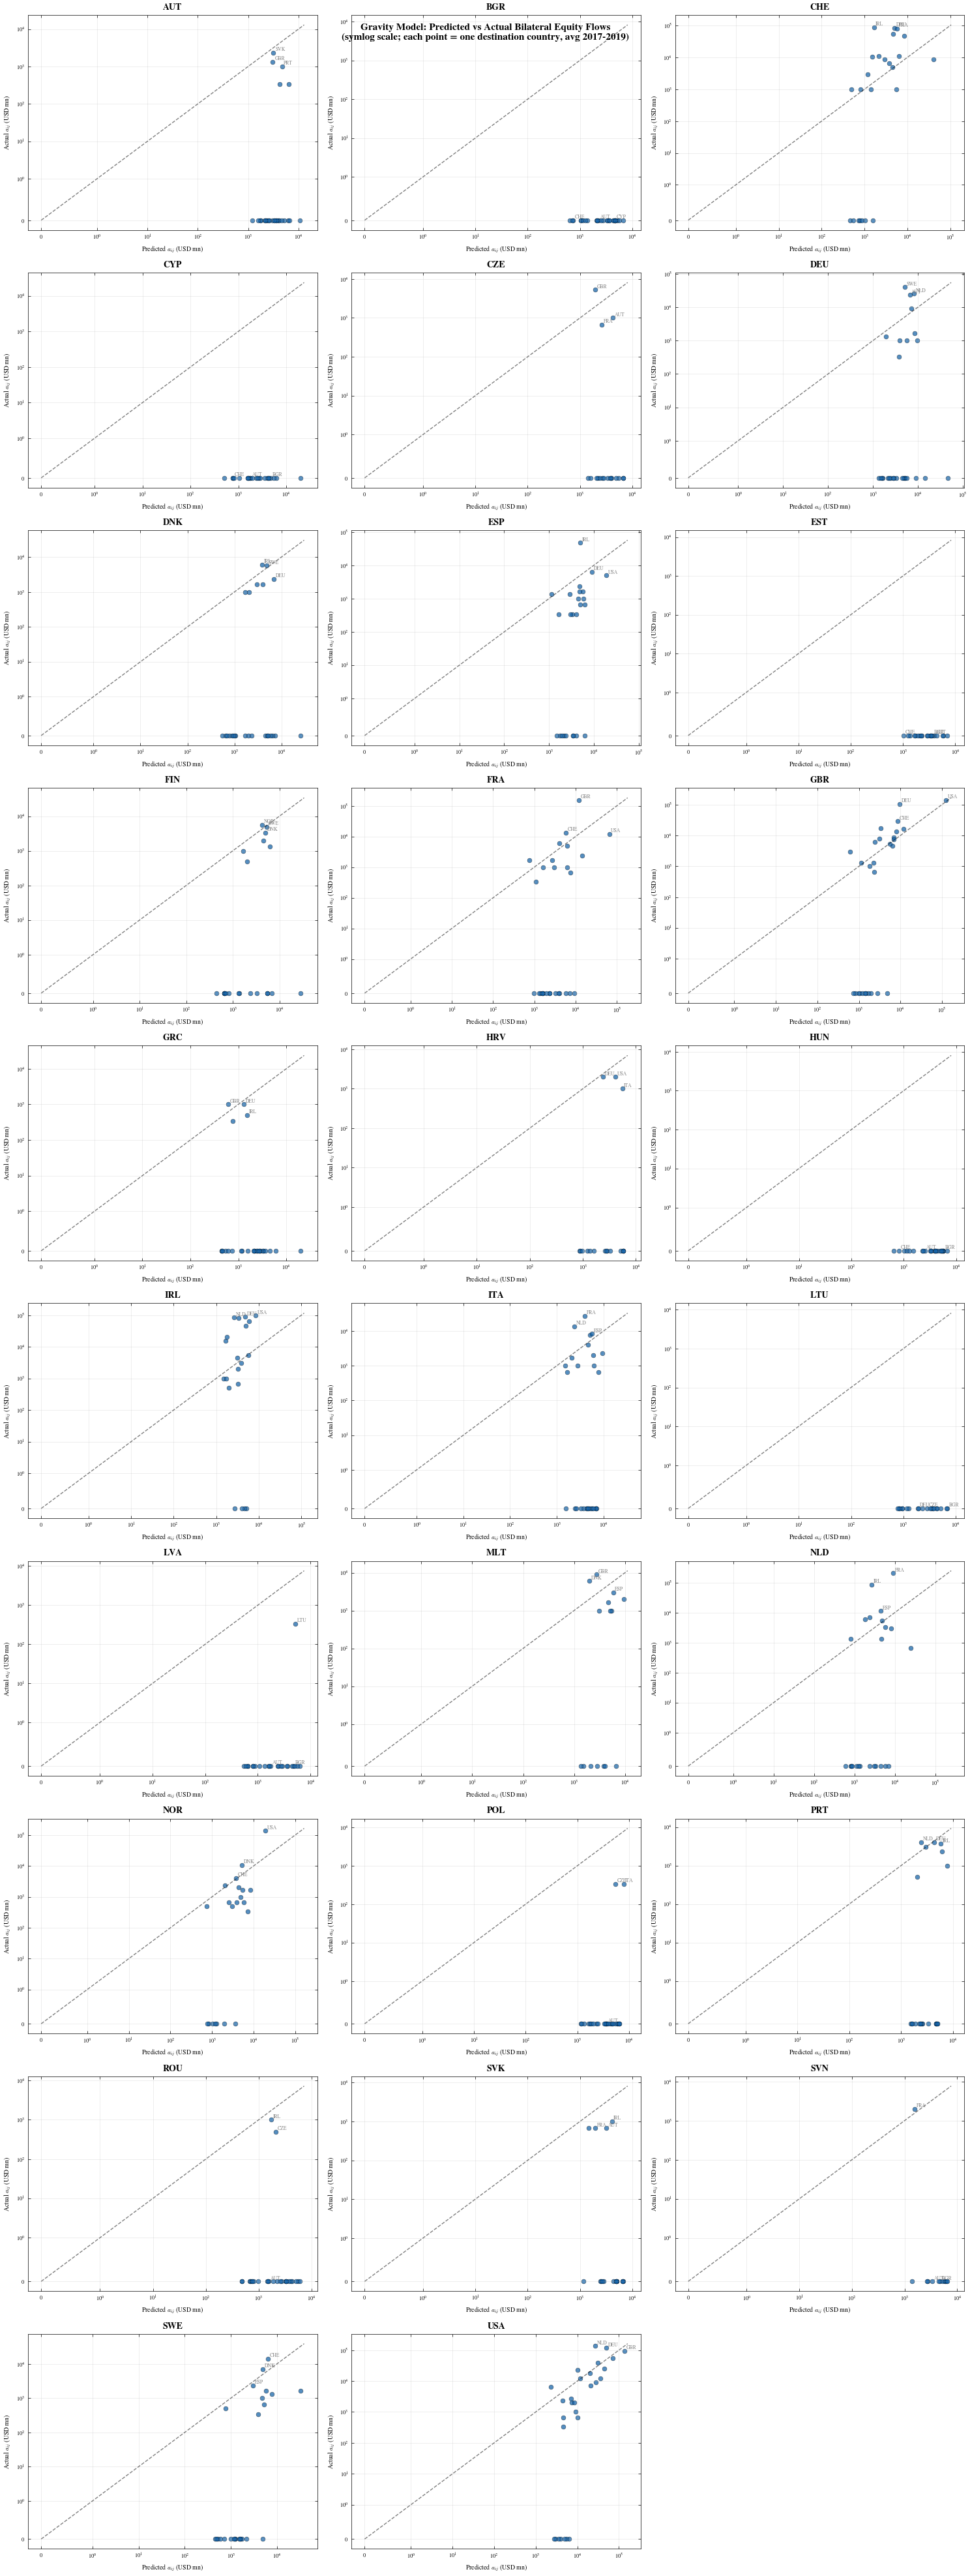

In [118]:
# ── Gravity model: predicted vs actual bilateral flows per source country ──
import math

pred = pd.read_csv("v4-gravity_pred.csv")

# Values in the CSV were divided by 1e6 before fitting; convert back to USD mn
pred["a_ij"]      = pred["a_ij"]      * 1e6
pred["a_ij_pred"] = pred["a_ij_pred"] * 1e6

# Average over years so each (i,j) pair has one point
pred_avg = pred.groupby(["iso3_i", "iso3_j"])[["a_ij", "a_ij_pred"]].mean().reset_index()

countries = sorted(pred_avg["iso3_i"].unique())
n_countries = len(countries)
ncols = 3
nrows = math.ceil(n_countries / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))
axes = axes.flatten()

for ax, country in zip(axes, countries):
    sub = pred_avg[pred_avg["iso3_i"] == country].copy()
    
    # Log scale for readability (flows span many orders of magnitude)
    x = sub["a_ij_pred"]
    y = sub["a_ij"]
    
    ax.scatter(x, y, s=25, alpha=0.7, edgecolors="black", linewidths=0.3, color="C0")
    
    # 45-degree perfect-fit line across the data range
    lim_min = min(x.min(), y.min()) * 0.8
    lim_max = max(x.max(), y.max()) * 1.2
    ax.plot([lim_min, lim_max], [lim_min, lim_max], "k--", linewidth=1, alpha=0.5, label="y = x")
    
    # Label a few outlier destination points
    for _, row in sub.nlargest(3, "a_ij").iterrows():
        ax.annotate(row["iso3_j"], xy=(row["a_ij_pred"], row["a_ij"]),
                    fontsize=5.5, color="grey", xytext=(2, 2), textcoords="offset points")
    
    ax.set_xscale("symlog", linthresh=1)
    ax.set_yscale("symlog", linthresh=1)
    ax.set_title(country, fontsize=10, fontweight="bold")
    ax.set_xlabel("Predicted $a_{ij}$ (USD mn)", fontsize=7)
    ax.set_ylabel("Actual $a_{ij}$ (USD mn)", fontsize=7)
    ax.tick_params(labelsize=6)
    ax.grid(True, alpha=0.3)

# Hide unused subplot panels
for ax in axes[n_countries:]:
    ax.set_visible(False)

plt.suptitle("Gravity Model: Predicted vs Actual Bilateral Equity Flows\n"
             "(symlog scale; each point = one destination country, avg 2017-2019)",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("dive/gravity_pred_vs_actual_grid.png", dpi=150, bbox_inches="tight")
plt.show()
